# Predicting Alzheimer's Conversion: A Machine Learning Approach to AI-Neuroscience

**Author**: Fajar Laksono

**Github**: http://fajrlaksono.github.io/

# 1. Summary

## Problem Statement

Alzheimer's disease affects over 55 million people worldwide, yet diagnosis typically occurs only after significant neurodegeneration has already taken place. The critical challenge is **early detection**: identifying individuals who are currently cognitively normal but will convert to Alzheimer's dementia within the next few years — while there is still a window for intervention.

This analysis addresses that challenge directly. Using the **OASIS (Open Access Series of Imaging Studies)** MRI dataset, we ask:

> *Can we predict which cognitively-normal individuals will later develop Alzheimer's dementia, using only their baseline MRI brain measurements and demographic data?*

---

## Approach

The analysis follows a structured AI-neuroscience pipeline across two complementary OASIS datasets:

| Dataset | Subjects | Purpose |
|---|---|---|
| Cross-Sectional | 436 subjects, single visit | Population-level EDA and biomarker profiling |
| Longitudinal | 373 subjects, multiple visits | Conversion prediction (Nondemented → Converted) |

**Pipeline overview:**
1. **Exploratory Data Analysis (Section 3)** — Understand dataset structure, missing values, feature distributions, and data quality
2. **Data Cleaning (Section 4)** — Remove irrelevant/constant columns, impute missing values, standardise names and encodings
3. **Descriptive Analysis (Section 5)** — Statistical comparisons, correlation analysis, Mann-Whitney U significance tests, and feature importance ranking
4. **Model Selection and Reasoning (Section 6)** — Justify the choice of classical machine learning over deep learning for this dataset size and task
5. **Conversion Prediction (Section 7)** — Train and evaluate four models with stratified cross-validation, then explain predictions using SHAP
6. **Conclusions and Recommendations (Section 8)** — Synthesise findings, map model outputs to neuroscience theory, and propose future directions

---

## Why This Matters

**From a clinical perspective**, most Alzheimer's trials fail because treatment begins too late. Identifying a conversion risk signal from a routine MRI — years before dementia onset — could enable targeted clinical trials, lifestyle interventions, and cognitive monitoring programmes.

**From an AI-neuroscience perspective**, explainability is non-negotiable in healthcare. This analysis deliberately prioritises *interpretable* machine learning (Logistic Regression, Random Forest, Gradient Boosting, SVM) over black-box deep learning, and uses **SHAP (SHapley Additive exPlanations)** to bridge model outputs directly back to known neuroscience biomarkers. Every prediction can be traced to a measurable biological signal — making this approach trustworthy for clinicians and researchers alike.

**From a data science perspective**, this is a realistic small-data problem. With only ~124 usable baseline subjects, the challenge reflects constraints common in medical imaging research: limited samples, class imbalance (roughly 3:1 Nondemented to Converted), and collinear features (eTIV/ASF). The methods chosen are validated for exactly these conditions.

---

## Key Highlights

### Dataset Overview
- **Cross-sectional dataset**: 436 subjects, single MRI visit — used for population-level feature profiling and CDR-stratified comparisons
- **Longitudinal dataset**: 373 records across multiple visits — used for conversion prediction (Visit 1 baseline only)
- **Baseline prediction cohort**: ~124 subjects (Nondemented and Converted at Visit 1; Demented subjects excluded to prevent label leakage)
- **7 model features**: `age`, `educ`, `ses`, `mmse`, `nwbv`, `etiv`, `asf`
- **CDR excluded from modelling**: CDR is the direct clinical dementia rating — using it as a feature would trivially leak the outcome; it is retained only for descriptive stratification

### Analysis Approach
- **Mann-Whitney U test** (non-parametric): chosen over t-tests because CDR and SES are ordinal and sample sizes are small and unequal
- **Spearman correlation**: appropriate for monotonic relationships between non-normally distributed neuroimaging variables
- **Feature importance pre-screening** (Section 5.4): ranked candidate predictors before modelling to inform feature selection rationale

### Model Development
- **Four models evaluated**: Logistic Regression, Random Forest, Gradient Boosting, SVM (RBF kernel)
- **Evaluation**: 5-fold stratified cross-validation; metrics include ROC-AUC, F1, and Recall (sensitivity prioritised for medical screening)
- **Class imbalance handling**: `class_weight='balanced'` applied to all models that support it
- **SHAP explainability**: TreeExplainer applied to Random Forest (beeswarm, bar, and waterfall plots) — individual-level explanations produced for high-risk and low-risk example subjects

### Key Findings
- **MMSE** (cognitive screening) and **nWBV** (normalised whole-brain volume) emerge as the two strongest predictors of conversion — consistent with amyloid cascade hypothesis (early cognitive and structural decline)
- **Education** shows a protective effect: higher education correlates with lower conversion risk, supporting the **cognitive reserve hypothesis**
- **Age** is a significant risk factor, though effect size is smaller than MMSE/nWBV
- **eTIV and ASF** are highly collinear (ASF ≈ 1,500,000 / eTIV) — both carry limited independent signal; dropping ASF is recommended before further modelling

### Practical Implications
- A simple MRI + cognitive screening battery (MMSE + nWBV) may be sufficient for early-stage risk stratification in primary care or clinical trial screening
- The SHAP waterfall plots enable per-patient explanation, supporting clinical adoption
- Education-based risk stratification could inform population-level prevention strategies

### Limitations
- **Small sample size** (~124 baseline subjects): models may not generalise to broader populations
- **Whole-brain aggregates only**: nWBV captures total volume loss but misses region-specific atrophy (hippocampus, entorhinal cortex) — the most diagnostically relevant areas in early Alzheimer's
- **No raw imaging data**: analysis is feature-based only; convolutional neural network approaches require the original MRI volumes
- **No amyloid/tau biomarkers**: gold-standard biological Alzheimer's markers are absent from this dataset
- **Demographically homogeneous cohort**: predominantly right-handed, single-institution sample — findings may not generalise across ethnicities or clinical sites

# 2. Preparation
## 2.1. Import Libraries and Configurations

In [1]:
# Import necessary libraries
import sys
import importlib.metadata
import shutil

import ipynbname
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import kagglehub

from pathlib import Path
from scipy import stats

# Print the versions
print("="*40)
print("===> Library Versions:")
print("="*40)

print("Python version: ", sys.version)
print(f"ipynbname package version: {importlib.metadata.version('ipynbname')}")
print("NumPy version: ", np.__version__)
print("Pandas version: ", pd.__version__)
print("Matplotlib version: ", matplotlib.__version__)
print("SciPy version: ", scipy.__version__)
print("Seaborn version: ", sns.__version__)
print(f"KaggleHub version: {importlib.metadata.version('kagglehub')}")

===> Library Versions:
Python version:  3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
ipynbname package version: 2025.8.0.0
NumPy version:  2.2.4
Pandas version:  2.2.3
Matplotlib version:  3.10.3
SciPy version:  1.15.2
Seaborn version:  0.13.2
KaggleHub version: 0.3.12


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.2. Configurations

In [2]:
# Workspace directory settings
print("="*40)
print("===> Workspace Directory:")
print("="*40)

notebook_path = Path(ipynbname.path())
notebook_dir = notebook_path.parent
print(f"Notebook directory: {notebook_dir}")
print(f"Notebook file path: {notebook_path}")

# Environment Variables
print("="*40) 
print("===> Environment Variables:")
print("="*40)

datasets_dir = notebook_dir.parent / "Datasets"
dataset_cross_filepath = datasets_dir / "oasis_cross-sectional.csv"
dataset_long_filepath = datasets_dir / "oasis_longitudinal.csv"
kaggle_url = "jboysen/mri-and-alzheimers"

print(f"Datasets directory: {datasets_dir}")
print(f"Cross-sectional data path: {dataset_cross_filepath}")
print(f"Longitudinal data path: {dataset_long_filepath}")
print(f"Datasets URL: {kaggle_url}")

===> Workspace Directory:
Notebook directory: d:\Project\Github\FajarLaksono\analytics\20260309-MRI-and-Alzheimers\Notebooks
Notebook file path: d:\Project\Github\FajarLaksono\analytics\20260309-MRI-and-Alzheimers\Notebooks\data-analysis_v1.ipynb
===> Environment Variables:
Datasets directory: d:\Project\Github\FajarLaksono\analytics\20260309-MRI-and-Alzheimers\Datasets
Cross-sectional data path: d:\Project\Github\FajarLaksono\analytics\20260309-MRI-and-Alzheimers\Datasets\oasis_cross-sectional.csv
Longitudinal data path: d:\Project\Github\FajarLaksono\analytics\20260309-MRI-and-Alzheimers\Datasets\oasis_longitudinal.csv
Datasets URL: jboysen/mri-and-alzheimers


## 2.3. Load Datasets

In [3]:
# Download datasets if not already present
if Path(dataset_cross_filepath).exists() and Path(dataset_long_filepath).exists():
    print("Datasets found successfully.")
else:
    print("One or both dataset files not found.")
    print("Initiating to download datasets...")

    # Download datasets from the provided URLs
    print("Target directory:", datasets_dir)
    cached_path = Path(kagglehub.dataset_download(kaggle_url))
    print("Downloaded to cache:", cached_path)

    # Extract the downloaded dataset
    for src in cached_path.iterdir():
        dst = datasets_dir / src.name
        print(f"Copying: {src} to {dst}")
        shutil.copy2(src, dst)
        print(f"Copied: {src.name}")    

    print("Datasets downloaded and copied successfully.")

# Load datasets into pandas DataFrames
df_cross = pd.read_csv(dataset_cross_filepath)
df_long = pd.read_csv(dataset_long_filepath)

print("Datasets loaded successfully.")

Datasets found successfully.
Datasets loaded successfully.


# 3. Exploratory Data Analysis
## 3.1. Dataset Shapes (Rows, Columns)

In [4]:
print("="*40)
print("===> Dataset Shapes:")
print("="*40)

print("Cross-sectional dataset shape:", df_cross.shape)
print("Longitudinal dataset shape:", df_long.shape)

===> Dataset Shapes:
Cross-sectional dataset shape: (436, 12)
Longitudinal dataset shape: (373, 15)


## 3.2. Dataset Preview

In [5]:
print("="*40)
print("===> Cross-sectional Dataset Preview:")
print("="*40)
display(df_cross.head())

print("="*40)
print("===> Longitudinal Dataset Preview:")
print("="*40)
display(df_long.head())

===> Cross-sectional Dataset Preview:


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


===> Longitudinal Dataset Preview:


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


## 3.3. Info

In [6]:
print("=== Cross-sectional Dataset Info: ===")
df_cross.info()

print("\n=== Longitudinal Dataset Info: ===")
df_long.info()

=== Cross-sectional Dataset Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    object 
 1   M/F     436 non-null    object 
 2   Hand    436 non-null    object 
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), object(3)
memory usage: 41.0+ KB

=== Longitudinal Dataset Info: ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID 

## 3.4. Missing Value

In [7]:
print("=== Cross-Sectional: Missing Values ===")
missing_cross = df_cross.isnull().sum()
missing_cross_pct = (missing_cross / len(df_cross) * 100).round(2)
display(pd.DataFrame({"Missing Count": missing_cross, "Missing (%)": missing_cross_pct})[missing_cross > 0])

print("\n=== Longitudinal: Missing Values ===")
missing_long = df_long.isnull().sum()
missing_long_pct = (missing_long / len(df_long) * 100).round(2)
display(pd.DataFrame({"Missing Count": missing_long, "Missing (%)": missing_long_pct})[missing_long > 0])

=== Cross-Sectional: Missing Values ===


,Missing Count,Missing (%)
Educ,201,46.10
SES,220,50.46
MMSE,201,46.10
CDR,201,46.10
Delay,416,95.41



=== Longitudinal: Missing Values ===


,Missing Count,Missing (%)
SES,19,5.09
MMSE,2,0.54


## 3.5. Check for Duplication

In [8]:
dup_cross = df_cross.duplicated().sum()
dup_long = df_long.duplicated().sum()

print(f"Cross-Sectional duplicate rows: {dup_cross}")
print(f"Longitudinal duplicate rows   : {dup_long}")

Cross-Sectional duplicate rows: 0
Longitudinal duplicate rows   : 0


## 3.6. Summary Statistics

In [9]:
print("=== Cross-Sectional: Summary Statistics ===")
display(df_cross.describe())

print("\n=== Longitudinal: Summary Statistics ===")
display(df_long.describe())

=== Cross-Sectional: Summary Statistics ===


,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
count,436.000000,235.000000,216.000000,235.00000,235.000000,436.000000,436.000000,436.000000,20.00000
mean,51.357798,3.178723,2.490741,27.06383,0.285106,1481.919725,0.791670,1.198894,20.55000
std,25.269862,1.311510,1.120593,3.69687,0.383405,158.740866,0.059937,0.128682,23.86249
min,18.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000,1.00000
25%,23.000000,2.000000,2.000000,26.00000,0.000000,1367.750000,0.742750,1.111750,2.75000
50%,54.000000,3.000000,2.000000,29.00000,0.000000,1475.500000,0.809000,1.190000,11.00000
75%,74.000000,4.000000,3.000000,30.00000,0.500000,1579.250000,0.842000,1.284250,30.75000
max,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.893000,1.563000,89.00000



=== Longitudinal: Summary Statistics ===


,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


## 3.7. Conclusion
### 3.7.1. Column Descriptions
Both datasets share a common set of clinical and neuroimaging features. Below is a description of each column and the meaning of its values.

#### 3.7.1.1. Demographic & Identifier Columns

| Column | Description | Values / Notes |
|---|---|---|
| `ID` / `Subject ID` | Unique identifier for each subject | e.g. `OAS1_0001_MR1` |
| `MRI ID` | Unique identifier for each MRI scan session (longitudinal only) | One subject may have multiple MRI IDs |
| `M/F` | Biological sex | `M` = Male, `F` = Female |
| `Hand` | Dominant hand | `R` = Right (all subjects in this dataset are right-handed) |
| `Age` | Subject's age at time of scan | In years |

#### 3.7.1.2. Socioeconomic & Cognitive Columns

| Column | Description | Values / Notes |
|---|---|---|
| `Educ` / `EDUC` | Education level | Cross-sectional: ordinal scale 1–5 (1 = less than high school, 5 = beyond college); Longitudinal: in years |
| `SES` | Socioeconomic status | Ordinal scale 1–5 (1 = highest status, 5 = lowest status) |
| `MMSE` | Mini-Mental State Examination score | 0–30; 30 = fully intact, ≤23 = cognitive impairment, ≤17 = severe impairment |
| `CDR` | Clinical Dementia Rating | 0 = no dementia, 0.5 = very mild, 1 = mild, 2 = moderate dementia |

#### 3.7.1.3. Neuroimaging Columns

| Column | Description | Values / Notes |
|---|---|---|
| `eTIV` | Estimated Total Intracranial Volume | In mm³; reflects skull/brain cavity size |
| `nWBV` | Normalized Whole Brain Volume | Ratio of brain tissue to total intracranial volume; decreases with age and dementia |
| `ASF` | Atlas Scaling Factor | Normalization factor to correct for head size differences across subjects |

#### 3.7.1.4. Longitudinal-only Columns

| Column | Description | Values / Notes |
|---|---|---|
| `Group` | Diagnosis group | `Nondemented`, `Demented`, `Converted` (converted from nondemented to demented during the study) |
| `Visit` | Visit number for the subject | Integer; visit 1 is the baseline |
| `MR Delay` | Days elapsed since the first MRI visit | 0 for baseline visit |
| `Delay` (cross-sectional) | Days between MRI session and clinical assessment | Mostly missing (95.4%) — not reliable for analysis |

### 3.7.2. Key EDA Findings

### 3.7.2.1. Dataset Overview
- The **cross-sectional dataset** contains **436 subjects** across 12 columns, covering a broad age range of 18–96 years (mean ~51). It captures a single MRI session per subject.
- The **longitudinal dataset** contains **373 scan records** from older subjects (aged 60–98, mean ~77), with up to 5 visits per subject tracked over time.

### 3.7.2.2. Missing Values
- The cross-sectional dataset has substantial missing data in key clinical columns: `Educ` (46%), `SES` (50%), `MMSE` (46%), and `CDR` (46%). These missing values are concentrated in younger subjects who were not clinically assessed (likely healthy controls).
- The `Delay` column is nearly entirely missing (95.4%) and should be excluded from analysis.
- The longitudinal dataset is much more complete, with only minor missingness in `SES` (5.1%) and `MMSE` (0.5%).

### 3.7.2.3. No Duplicates
- Neither dataset contains duplicate rows, confirming data integrity.

### 3.7.2.4. Cognitive Health Distribution
- Mean `MMSE` scores of ~27 in both datasets indicate that most subjects have normal to mildly impaired cognition (threshold for impairment is ≤23).
- Mean `CDR` scores of ~0.29 reflect that the majority of subjects have no dementia (CDR = 0), with a portion in the very mild range (CDR = 0.5).

### 3.7.2.5. Brain Volume Differences
- The longitudinal dataset (older subjects, mean age 77) shows a lower mean `nWBV` (0.73) compared to the cross-sectional dataset (mean age 51, mean `nWBV` 0.79). This is consistent with known age-related brain atrophy.
- `nWBV` is a critical indicator — lower values may correlate with dementia progression and should be a key feature in predictive modelling.

### 3.7.2.6. Handedness
- All subjects in both datasets are right-handed (`Hand = R`), meaning handedness is a constant and provides no discriminative power for analysis.

### 3.7.2.7. Next Steps
- Handle missing values in the cross-sectional dataset (imputation or subsetting to assessed subjects only).
- Investigate the relationship between `CDR`, `MMSE`, and `nWBV` as primary indicators of Alzheimer's progression.
- In the longitudinal dataset, analyse brain volume change (`nWBV`) across visits within the `Demented` and `Converted` groups.

### 3.7.3. Dataset Limitations

This dataset provides a useful starting point for AI-neuroscience research, but several structural limitations constrain the depth of analysis and the capability of any AI model built on top of it.

#### 3.7.3.1. Whole-Brain Aggregates Only — No Region-Specific Volumes

The dataset provides only **three MRI-derived features**: `eTIV`, `nWBV`, and `ASF` — all of which are **whole-brain aggregate measures**. They describe the total brain volume relative to skull size, but do not capture structure-level detail.

In Alzheimer's disease, neurodegeneration is **regionally specific** and follows a well-established progression pattern:

| Brain Region | Role | Why It Matters for Alzheimer's |
|---|---|---|
| **Hippocampus** | Memory formation and spatial navigation | First region to show atrophy in early Alzheimer's; hippocampal volume loss is a primary biomarker |
| **Entorhinal Cortex** | Memory consolidation, gateway to hippocampus | Shows tau pathology (neurofibrillary tangles) before symptoms appear |
| **Parahippocampal Gyrus** | Contextual memory | Atrophies in early-to-mid stage |
| **Amygdala** | Emotional processing | Affected in mid-stage; linked to behavioural symptoms |
| **Prefrontal Cortex** | Executive function, decision-making | Affected in moderate-to-severe stages |

By using only `nWBV` (whole-brain), we **miss the early, localised signal** that region-specific volumes would provide. An AI model trained on this data cannot detect early-stage Alzheimer's with high sensitivity — it can only detect cases where brain atrophy has become widespread enough to reduce total brain volume, which typically indicates mid-to-late stage disease.

**Implication**: AI models built here may underperform on early detection tasks. Region-specific volumetric data (available from full FreeSurfer segmentation pipelines on raw OASIS MRI scans) would significantly improve sensitivity.

#### 3.7.3.2. `eTIV` and `ASF` Are Redundant

`ASF` is mathematically derived from `eTIV`:

```
ASF ≈ 1,500,000 / eTIV
```

Keeping both in a model introduces **multicollinearity** — the two features carry the same information with opposite signs of correlation. This inflates coefficient variance in linear models and distorts feature importance in tree-based models. One of the two should be dropped before modelling; `ASF` is typically removed since `eTIV` is the raw measure.

#### 3.7.3.3. Small Sample Size

- Cross-sectional (clinically assessed subset): **235 subjects**
- Longitudinal: **371 scan records** from ~150 unique subjects

These are small by modern AI standards. Deep learning models in neuroscience typically require thousands to tens of thousands of subjects. Models trained here will have high variance and limited generalisability. Cross-validation and regularisation will be essential.

#### 3.7.3.4. No Raw Imaging Data

The dataset contains only **tabular summaries** of MRI scans — not the raw 3D voxel images. Cutting-edge AI-neuroscience work (e.g., convolutional neural networks for Alzheimer's detection from MRI) requires raw image data. The full OASIS dataset provides NIfTI image files; this Kaggle version is a pre-extracted feature table only.

#### 3.7.3.5. Class Imbalance in Longitudinal Data

The longitudinal dataset has a notable imbalance across diagnosis groups:
- `Nondemented` (0): 190 records
- `Demented` (2): 144 records
- `Converted` (1): 37 records

The `Converted` class — arguably the most clinically important group for **early detection** — represents only ~10% of the data. AI models trained without addressing this imbalance will be biased toward the majority classes.

# 4. Data Cleaning

## 4.1. Drop Constant and Irrelevant Columns

- `Hand`: All subjects are right-handed — constant, no analytical value.
- `Delay` (cross-sectional): 95.4% missing — not recoverable.

In [10]:
df_cross_clean = df_cross.drop(columns=["Hand", "Delay"])
df_long_clean = df_long.drop(columns=["Hand"])

print("Cross-sectional columns after drop:", df_cross_clean.columns.tolist())
print("Longitudinal columns after drop    :", df_long_clean.columns.tolist())

Cross-sectional columns after drop: ['ID', 'M/F', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
Longitudinal columns after drop    : ['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']


## 4.2. Handle Missing Values — Cross-Sectional

The missing values in `Educ`, `SES`, `MMSE`, and `CDR` (~46–50%) occur together in the same rows — these are younger subjects who were not clinically assessed. Since the missingness is structural (not random), imputation would introduce unreliable assumptions.

**Strategy**: Subset to rows where `CDR` is not null, retaining only clinically-assessed subjects.

In [11]:
before = len(df_cross_clean)
df_cross_clean = df_cross_clean.dropna(subset=["CDR"])
after = len(df_cross_clean)

print(f"Cross-sectional rows: {before} → {after} (dropped {before - after} unclinically-assessed rows)")
print("\nRemaining missing values:")
print(df_cross_clean.isnull().sum()[df_cross_clean.isnull().sum() > 0])

Cross-sectional rows: 436 → 235 (dropped 201 unclinically-assessed rows)

Remaining missing values:
SES    19
dtype: int64


## 4.3. Handle Missing Values — Longitudinal

- `SES` (5.1% missing): Impute with median per `Group` to preserve group-level distribution.
- `MMSE` (0.54%, ~2 rows): Drop rows — too few to warrant imputation.

In [12]:
# Impute SES with median per Group
df_long_clean["SES"] = df_long_clean.groupby("Group")["SES"].transform(
    lambda x: x.fillna(x.median())
)

# Drop the ~2 rows where MMSE is missing
before = len(df_long_clean)
df_long_clean = df_long_clean.dropna(subset=["MMSE"])
after = len(df_long_clean)

print(f"Longitudinal rows: {before} → {after} (dropped {before - after} rows with missing MMSE)")
print("\nRemaining missing values:")
missing = df_long_clean.isnull().sum()
print(missing[missing > 0] if missing[missing > 0].any() else "None")

Longitudinal rows: 373 → 371 (dropped 2 rows with missing MMSE)

Remaining missing values:
None


## 4.4. Standardise Column Names

Rename columns to consistent `snake_case` for easier programmatic access:
- Remove spaces (e.g. `Subject ID` → `subject_id`)
- Normalise capitalisation (e.g. `M/F` → `sex`, `EDUC` / `Educ` → `educ`)

In [13]:
cross_rename = {
    "ID": "id",
    "M/F": "sex",
    "Age": "age",
    "Educ": "educ",
    "SES": "ses",
    "MMSE": "mmse",
    "CDR": "cdr",
    "eTIV": "etiv",
    "nWBV": "nwbv",
    "ASF": "asf",
}

long_rename = {
    "Subject ID": "subject_id",
    "MRI ID": "mri_id",
    "Group": "group",
    "Visit": "visit",
    "MR Delay": "mr_delay",
    "M/F": "sex",
    "Age": "age",
    "EDUC": "educ",
    "SES": "ses",
    "MMSE": "mmse",
    "CDR": "cdr",
    "eTIV": "etiv",
    "nWBV": "nwbv",
    "ASF": "asf",
}

df_cross_clean = df_cross_clean.rename(columns=cross_rename)
df_long_clean = df_long_clean.rename(columns=long_rename)

print("Cross-sectional columns:", df_cross_clean.columns.tolist())
print("Longitudinal columns    :", df_long_clean.columns.tolist())

Cross-sectional columns: ['id', 'sex', 'age', 'educ', 'ses', 'mmse', 'cdr', 'etiv', 'nwbv', 'asf']
Longitudinal columns    : ['subject_id', 'mri_id', 'group', 'visit', 'mr_delay', 'sex', 'age', 'educ', 'ses', 'mmse', 'cdr', 'etiv', 'nwbv', 'asf']


## 4.5. Encode Categorical Columns

- `sex`: `M` → `0`, `F` → `1`
- `group` (longitudinal only): `Nondemented` → `0`, `Converted` → `1`, `Demented` → `2`

In [14]:
sex_map = {"M": 0, "F": 1}
df_cross_clean["sex"] = df_cross_clean["sex"].map(sex_map)
df_long_clean["sex"] = df_long_clean["sex"].map(sex_map)

group_map = {"Nondemented": 0, "Converted": 1, "Demented": 2}
df_long_clean["group"] = df_long_clean["group"].map(group_map)

print("Cross-sectional sex value counts:\n", df_cross_clean["sex"].value_counts().to_dict())
print("\nLongitudinal sex value counts   :\n", df_long_clean["sex"].value_counts().to_dict())
print("\nLongitudinal group value counts :\n", df_long_clean["group"].value_counts().sort_index().to_dict())

Cross-sectional sex value counts:
 {1: 156, 0: 79}

Longitudinal sex value counts   :
 {1: 211, 0: 160}

Longitudinal group value counts :
 {0: 190, 1: 37, 2: 144}


## 4.6. Validate Value Ranges

Ensure no values fall outside clinically valid ranges:
- `mmse`: 0–30
- `cdr`: 0, 0.5, 1, 2
- `ses`: 1–5
- `educ`: 1–5 (cross-sectional); reasonable years range for longitudinal

In [15]:
def check_range(df, label, col, min_val, max_val):
    violations = df[(df[col] < min_val) | (df[col] > max_val)]
    status = "OK" if violations.empty else f"{len(violations)} violation(s)"
    print(f"[{label}] {col} in [{min_val}, {max_val}]: {status}")

valid_cdr = {0, 0.5, 1, 2}
for df, label in [(df_cross_clean, "Cross"), (df_long_clean, "Long")]:
    check_range(df, label, "mmse", 0, 30)
    check_range(df, label, "ses", 1, 5)
    invalid_cdr = df[~df["cdr"].isin(valid_cdr)]
    print(f"[{label}] cdr valid values {{0, 0.5, 1, 2}}: {'OK' if invalid_cdr.empty else f'{len(invalid_cdr)} violation(s)'}")

check_range(df_cross_clean, "Cross", "educ", 1, 5)
check_range(df_long_clean, "Long", "educ", 1, 30)

[Cross] mmse in [0, 30]: OK
[Cross] ses in [1, 5]: OK
[Cross] cdr valid values {0, 0.5, 1, 2}: OK
[Long] mmse in [0, 30]: OK
[Long] ses in [1, 5]: OK
[Long] cdr valid values {0, 0.5, 1, 2}: OK
[Cross] educ in [1, 5]: OK
[Long] educ in [1, 30]: OK


## 4.7. Summary of Cleaned Datasets

In [16]:
print("="*40)
print("===> Cross-Sectional (Cleaned):")
print("="*40)
print(f"Shape: {df_cross_clean.shape}")
print(f"Missing values: {df_cross_clean.isnull().sum().sum()}")
display(df_cross_clean.head())

print("="*40)
print("===> Longitudinal (Cleaned):")
print("="*40)
print(f"Shape: {df_long_clean.shape}")
print(f"Missing values: {df_long_clean.isnull().sum().sum()}")
display(df_long_clean.head())

===> Cross-Sectional (Cleaned):
Shape: (235, 10)
Missing values: 19


,id,sex,age,educ,ses,mmse,cdr,etiv,nwbv,asf
0,OAS1_0001_MR1,1,74,2.0,3.0,29.0,0.0,1344,0.743,1.306
1,OAS1_0002_MR1,1,55,4.0,1.0,29.0,0.0,1147,0.810,1.531
2,OAS1_0003_MR1,1,73,4.0,3.0,27.0,0.5,1454,0.708,1.207
8,OAS1_0010_MR1,0,74,5.0,2.0,30.0,0.0,1636,0.689,1.073
9,OAS1_0011_MR1,1,52,3.0,2.0,30.0,0.0,1321,0.827,1.329


===> Longitudinal (Cleaned):
Shape: (371, 14)
Missing values: 0


,subject_id,mri_id,group,visit,mr_delay,sex,age,educ,ses,mmse,cdr,etiv,nwbv,asf
0,OAS2_0001,OAS2_0001_MR1,0,1,0,0,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,0,2,457,0,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,2,1,0,0,75,12,3.0,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,2,2,560,0,76,12,3.0,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,2,3,1895,0,80,12,3.0,22.0,0.5,1698,0.701,1.034


# 5. Descriptive Analysis
## 5.1. Central Tendency & Dispersion
### 5.1.1. Describe

In [17]:
print("=== Cross-Sectional: Summary Statistics ===")
display(df_cross_clean.describe())

print("\n=== Longitudinal: Summary Statistics ===")
display(df_cross_clean.describe())

=== Cross-Sectional: Summary Statistics ===


,sex,age,educ,ses,mmse,cdr,etiv,nwbv,asf
count,235.000000,235.000000,235.000000,216.000000,235.00000,235.000000,235.000000,235.000000,235.000000
mean,0.663830,72.344681,3.178723,2.490741,27.06383,0.285106,1459.497872,0.749132,1.216511
std,0.473406,12.091369,1.311510,1.120593,3.69687,0.383405,160.368070,0.047906,0.129427
min,0.000000,33.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000
25%,0.000000,66.000000,2.000000,2.000000,26.00000,0.000000,1348.000000,0.713500,1.133500
50%,1.000000,73.000000,3.000000,2.000000,29.00000,0.000000,1447.000000,0.747000,1.213000
75%,1.000000,81.000000,4.000000,3.000000,30.00000,0.500000,1548.000000,0.784000,1.302000
max,1.000000,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.847000,1.563000



=== Longitudinal: Summary Statistics ===


,sex,age,educ,ses,mmse,cdr,etiv,nwbv,asf
count,235.000000,235.000000,235.000000,216.000000,235.00000,235.000000,235.000000,235.000000,235.000000
mean,0.663830,72.344681,3.178723,2.490741,27.06383,0.285106,1459.497872,0.749132,1.216511
std,0.473406,12.091369,1.311510,1.120593,3.69687,0.383405,160.368070,0.047906,0.129427
min,0.000000,33.000000,1.000000,1.000000,14.00000,0.000000,1123.000000,0.644000,0.881000
25%,0.000000,66.000000,2.000000,2.000000,26.00000,0.000000,1348.000000,0.713500,1.133500
50%,1.000000,73.000000,3.000000,2.000000,29.00000,0.000000,1447.000000,0.747000,1.213000
75%,1.000000,81.000000,4.000000,3.000000,30.00000,0.500000,1548.000000,0.784000,1.302000
max,1.000000,96.000000,5.000000,5.000000,30.00000,2.000000,1992.000000,0.847000,1.563000


### 5.1.2. Median

In [18]:
print("=== Cross-Sectional: Median ===")
display(df_cross_clean.select_dtypes(include="number").median())

print("\n=== Longitudinal: Median ===")
display(df_long_clean.select_dtypes(include="number").median())


=== Cross-Sectional: Median ===


sex        1.000
age       73.000
educ       3.000
ses        2.000
mmse      29.000
cdr        0.000
etiv    1447.000
nwbv       0.747
asf        1.213
dtype: float64


=== Longitudinal: Median ===


group          0.000
visit          2.000
mr_delay     552.000
sex            1.000
age           77.000
educ          15.000
ses            2.000
mmse          29.000
cdr            0.000
etiv        1471.000
nwbv           0.729
asf            1.193
dtype: float64

### 5.1.3. Interquartile Range (IQR)

In [19]:
print("=== Cross-Sectional: IQR ===")
display(df_cross_clean.select_dtypes(include="number").quantile([0.25, 0.5, 0.75]))

print("\n=== Longitudinal: IQR ===")
display(df_long_clean.select_dtypes(include="number").quantile([0.25, 0.5, 0.75]))

=== Cross-Sectional: IQR ===


,sex,age,educ,ses,mmse,cdr,etiv,nwbv,asf
0.25,0.0,66.0,2.0,2.0,26.0,0.0,1348.0,0.7135,1.1335
0.50,1.0,73.0,3.0,2.0,29.0,0.0,1447.0,0.7470,1.2130
0.75,1.0,81.0,4.0,3.0,30.0,0.5,1548.0,0.7840,1.3020



=== Longitudinal: IQR ===


,group,visit,mr_delay,sex,age,educ,ses,mmse,cdr,etiv,nwbv,asf
0.25,0.0,1.0,0.0,0.0,71.0,12.0,2.0,27.0,0.0,1358.5,0.700,1.0985
0.50,0.0,2.0,552.0,1.0,77.0,15.0,2.0,29.0,0.0,1471.0,0.729,1.1930
0.75,2.0,2.0,869.5,1.0,82.0,16.0,3.0,30.0,0.5,1598.0,0.756,1.2920


## 5.2. Distribution Analysis

### 5.2.1. Histogram

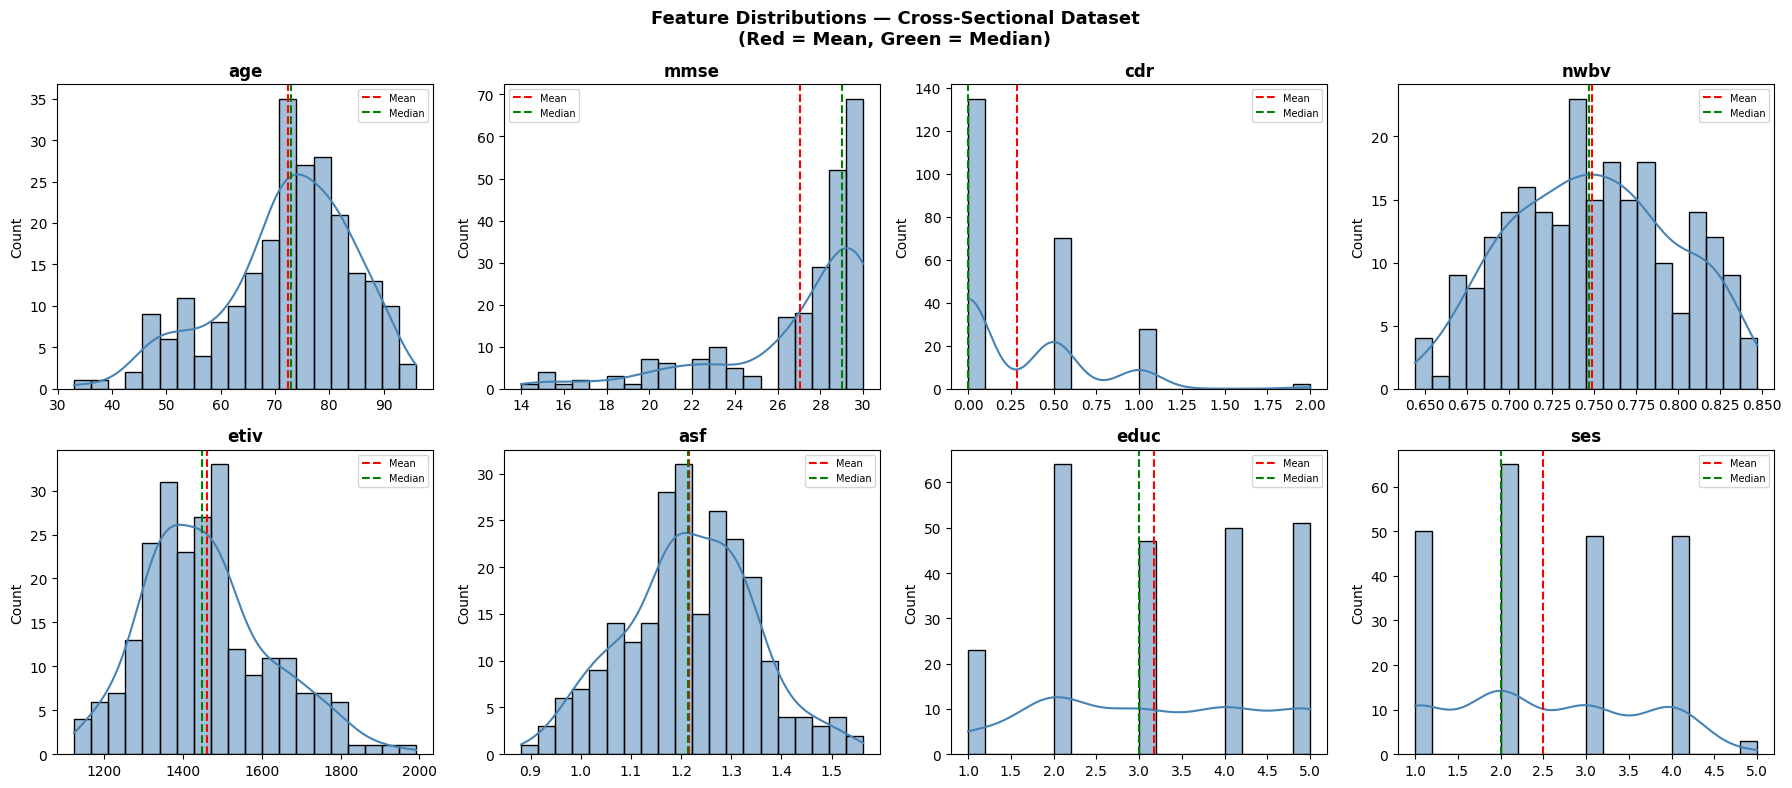

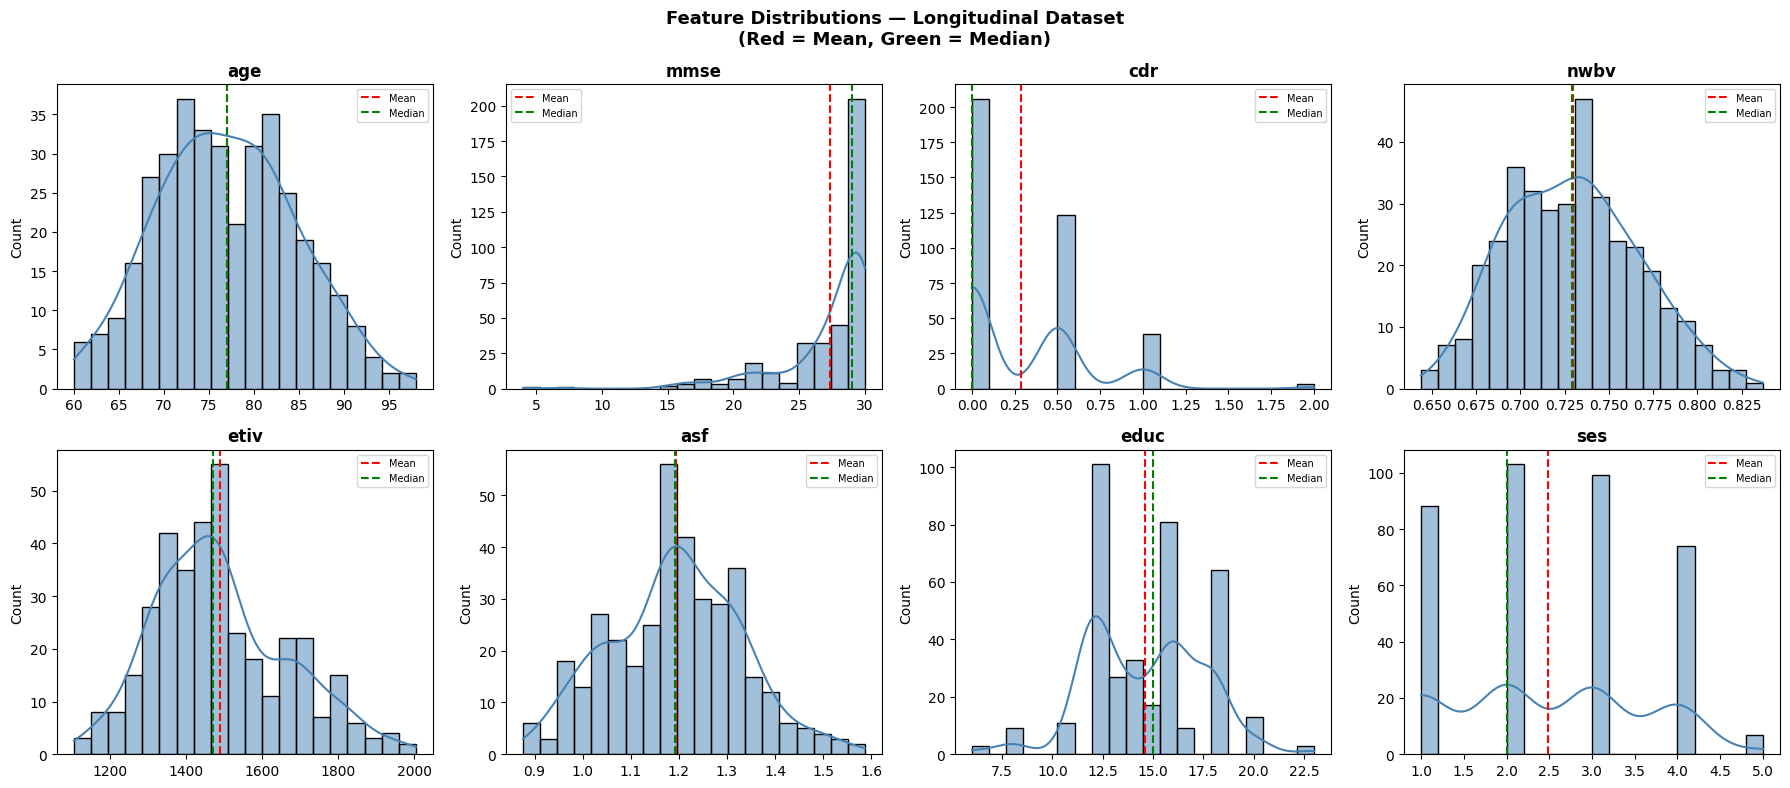

In [20]:
features = ['age', 'mmse', 'cdr', 'nwbv', 'etiv', 'asf', 'educ', 'ses']

for df, title in [(df_cross_clean, 'Cross-Sectional'), (df_long_clean, 'Longitudinal')]:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(f"Feature Distributions — {title} Dataset\n(Red = Mean, Green = Median)",
                 fontsize=13, fontweight='bold')
    for ax, col in zip(axes.flat, features):
        sns.histplot(df[col].dropna(), kde=True, bins=20, color='steelblue', ax=ax)
        ax.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
        ax.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=1.5, label='Median')
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

### 5.2.2. Boxplot

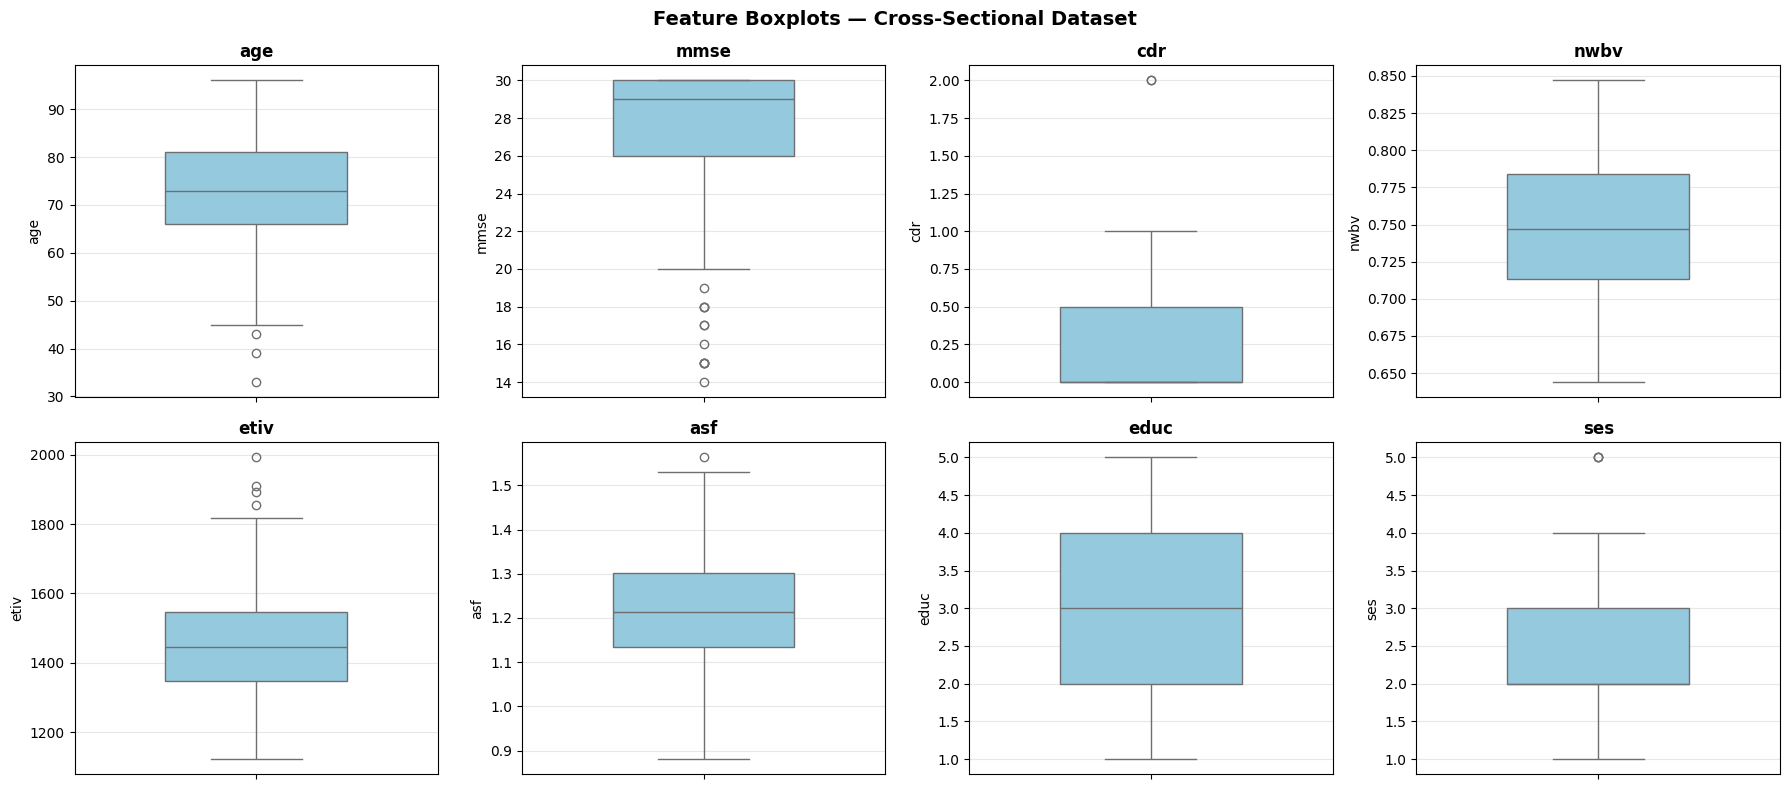

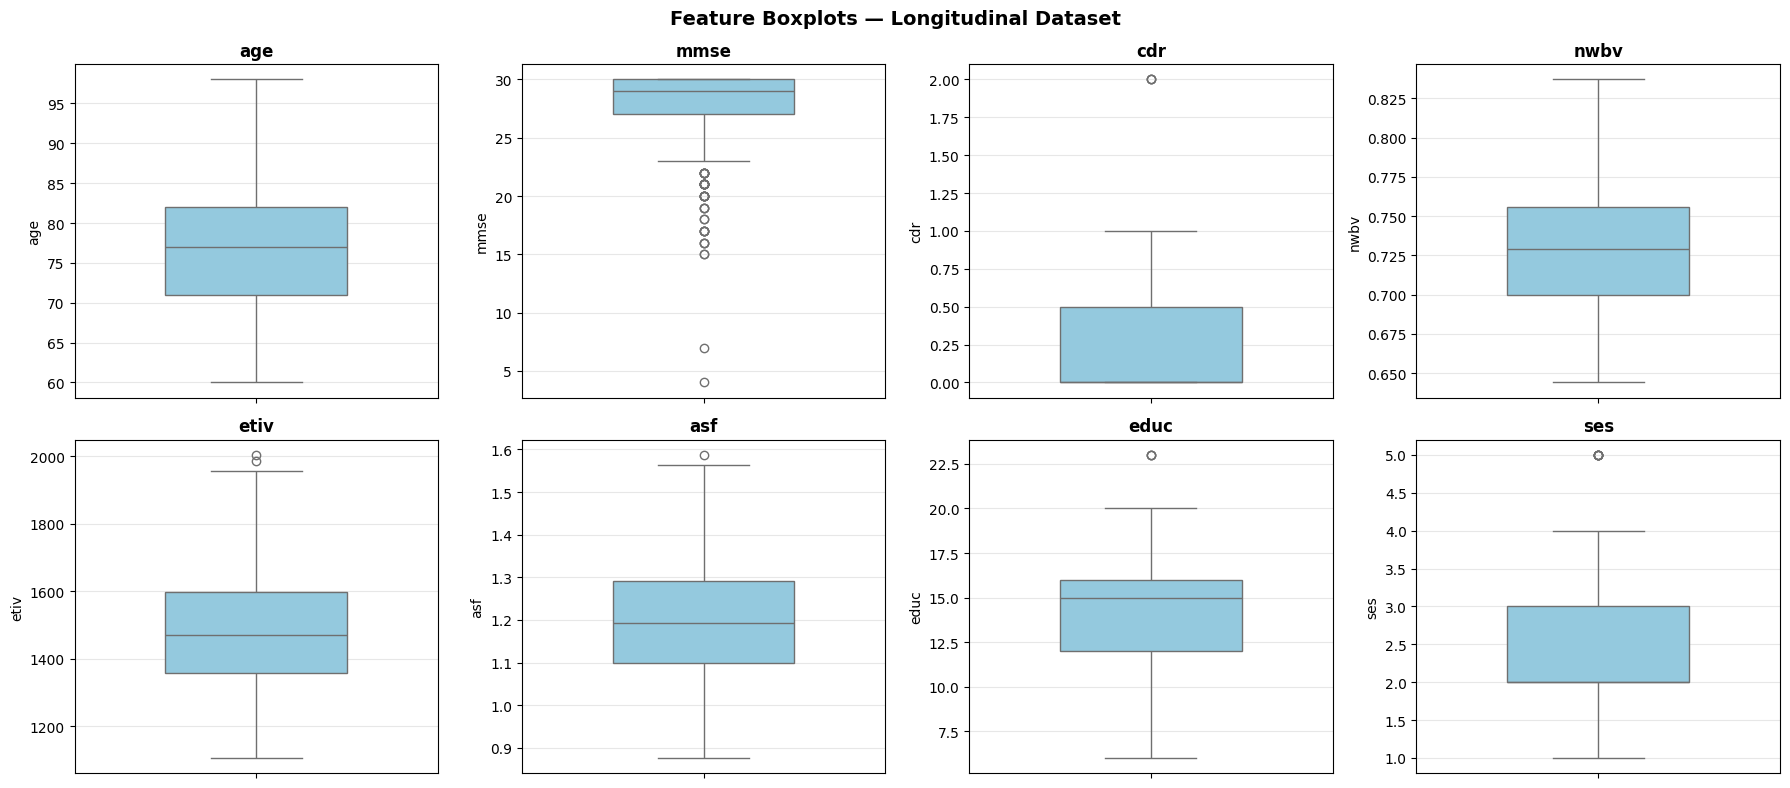

In [21]:
features = ['age', 'mmse', 'cdr', 'nwbv', 'etiv', 'asf', 'educ', 'ses']

for df, title in [(df_cross_clean, 'Cross-Sectional'), (df_long_clean, 'Longitudinal')]:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(f"Feature Boxplots — {title} Dataset", fontsize=14, fontweight='bold')
    for ax, col in zip(axes.flat, features):
        sns.boxplot(y=df[col].dropna(), color='skyblue', ax=ax, width=0.5)
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('')
        ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

### 5.2.3. Categorical Features Analysis

=== Cross-Sectional: Categorical Features ===


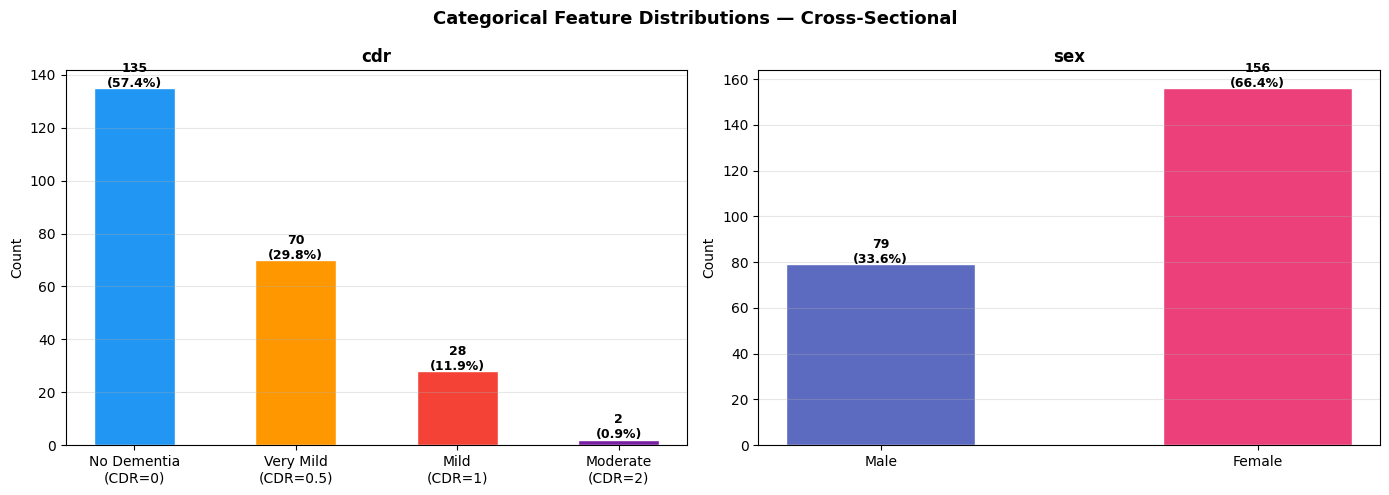


=== Longitudinal: Categorical Features ===


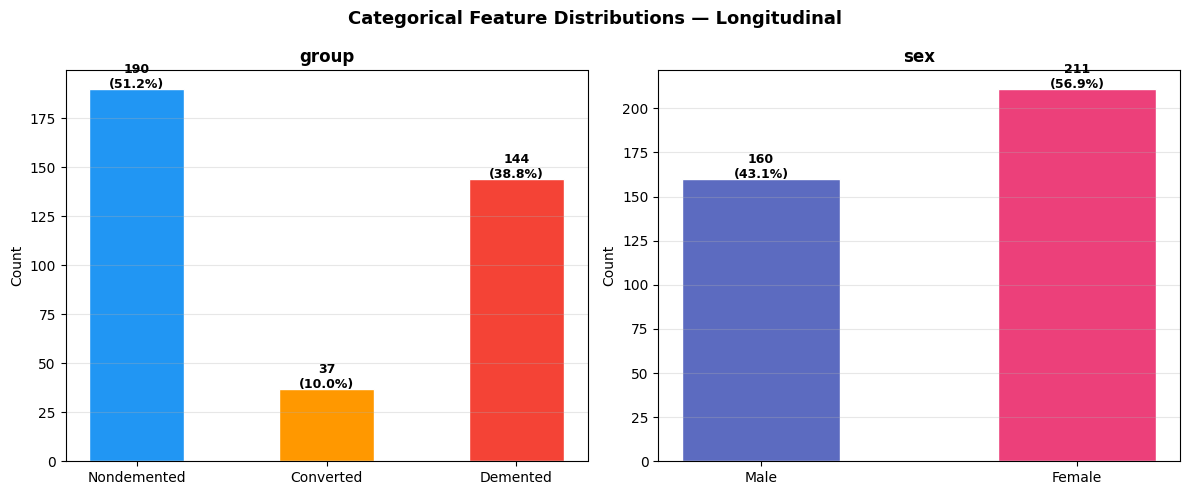

In [22]:
# Shared palette/label dicts — used by later cells
palette_group = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
palette_sex   = {0: '#5C6BC0', 1: '#EC407A'}
cdr_palette   = {0.0: '#2196F3', 0.5: '#FF9800', 1.0: '#F44336', 2.0: '#7B1FA2'}
group_labels  = {0: 'Nondemented', 1: 'Converted', 2: 'Demented'}
sex_labels    = {0: 'Male', 1: 'Female'}
cdr_labels    = {0.0: 'No Dementia\n(CDR=0)', 0.5: 'Very Mild\n(CDR=0.5)',
                 1.0: 'Mild\n(CDR=1)',        2.0: 'Moderate\n(CDR=2)'}

# Cross-sectional: CDR and Sex
print("=== Cross-Sectional: Categorical Features ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Categorical Feature Distributions — Cross-Sectional", fontsize=13, fontweight='bold')

for ax, (col, label_map, palette) in zip(axes, [
    ('cdr', cdr_labels,  cdr_palette),
    ('sex', sex_labels,  palette_sex),
]):
    counts = df_cross_clean[col].value_counts().sort_index()
    labels = [label_map[k] for k in counts.index]
    bars = ax.bar(labels, counts.values, color=[palette[k] for k in counts.index], edgecolor='white', width=0.5)
    for bar, count in zip(bars, counts.values):
        pct = count / len(df_cross_clean) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Longitudinal: Group and Sex
print("\n=== Longitudinal: Categorical Features ===")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Categorical Feature Distributions — Longitudinal", fontsize=13, fontweight='bold')

for ax, (col, label_map, palette) in zip(axes, [
    ('group', group_labels, palette_group),
    ('sex',   sex_labels,   palette_sex),
]):
    counts = df_long_clean[col].value_counts().sort_index()
    labels = [label_map[k] for k in counts.index]
    bars = ax.bar(labels, counts.values, color=[palette[k] for k in counts.index], edgecolor='white', width=0.5)
    for bar, count in zip(bars, counts.values):
        pct = count / len(df_long_clean) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 5.2.4. Skewness & Kurtosis

Shape analysis to understand feature distributions — relevant for choosing appropriate statistical tests (parametric vs non-parametric) before modelling.

=== Skewness & Kurtosis — Cross-Sectional ===


,Skewness,Skew Type,Kurtosis
Feature,,,
age,-0.6487,Moderate,0.0716
mmse,-1.6065,High,1.9632
cdr,1.3676,High,2.1660
nwbv,0.0037,Symmetric,-0.8133
etiv,0.5944,Moderate,0.1896
asf,-0.0148,Symmetric,-0.1645
educ,-0.0137,Symmetric,-1.2224
ses,0.1635,Symmetric,-1.1400


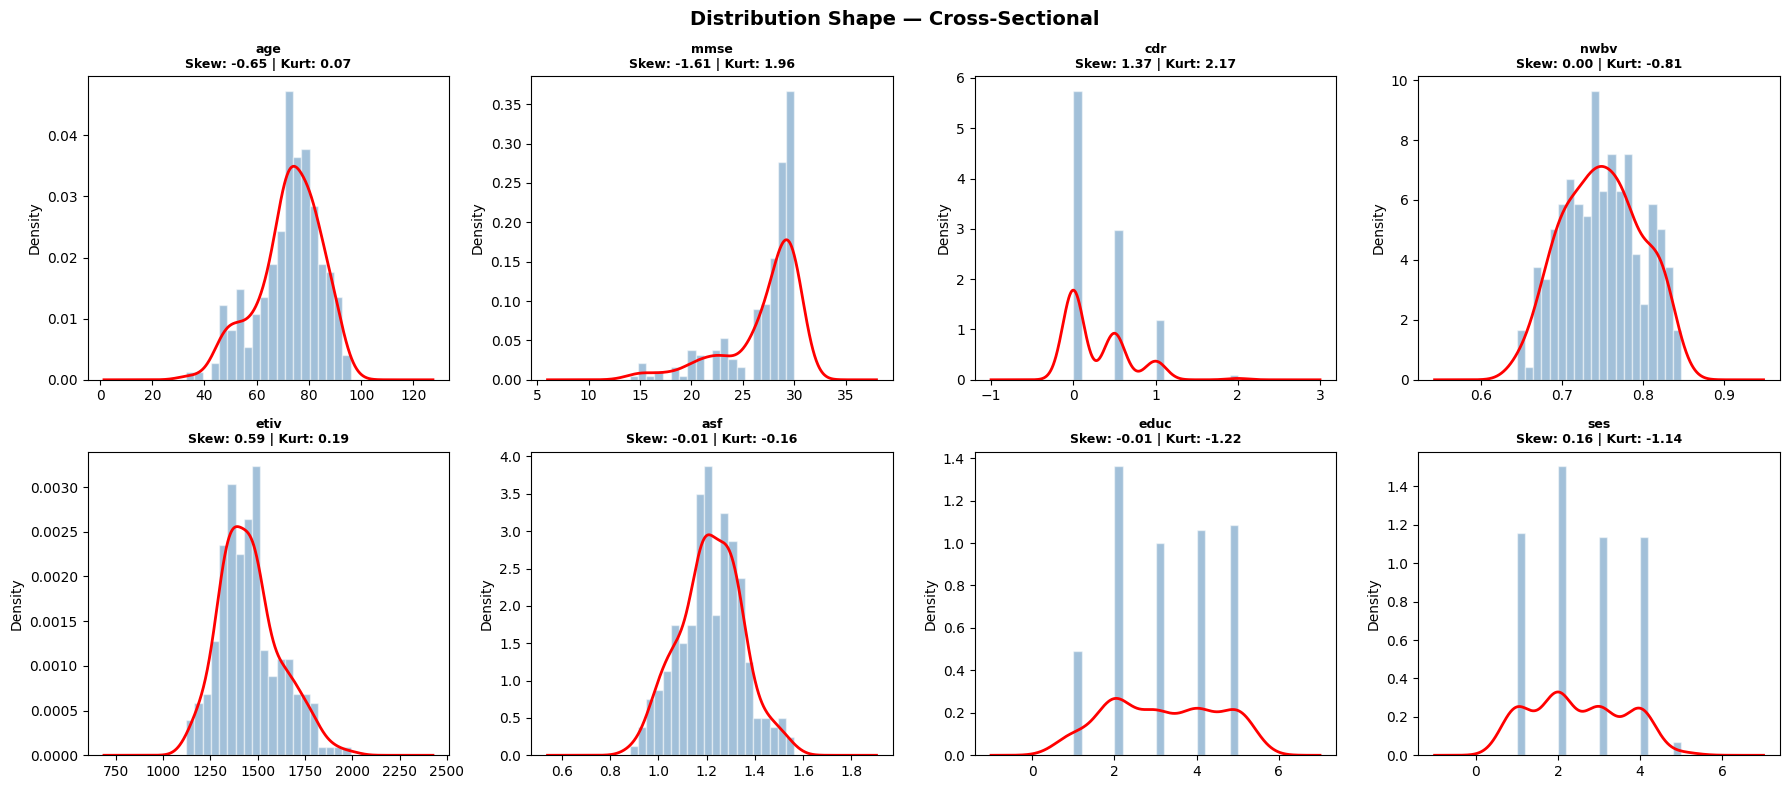

=== Skewness & Kurtosis — Longitudinal ===


,Skewness,Skew Type,Kurtosis
Feature,,,
age,0.1393,Symmetric,-0.4242
mmse,-2.3661,High,7.5158
cdr,1.3483,High,2.3675
nwbv,0.2374,Symmetric,-0.4302
etiv,0.5139,Moderate,-0.1184
asf,0.0587,Symmetric,-0.2358
educ,-0.0368,Symmetric,-0.0086
ses,0.1615,Symmetric,-1.0396


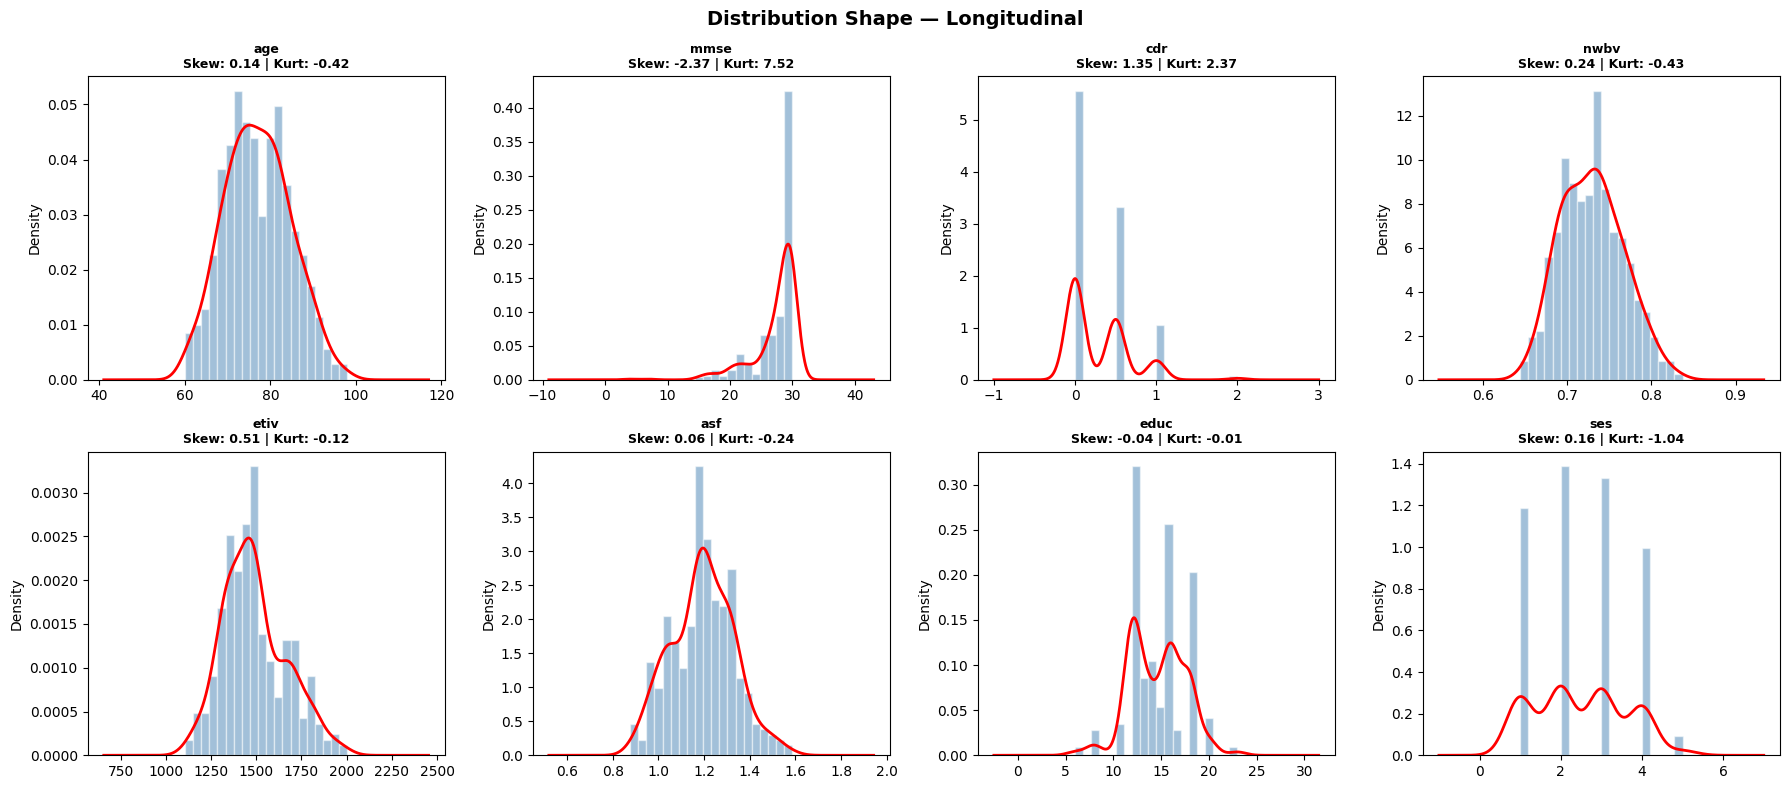

In [23]:
features = ['age', 'mmse', 'cdr', 'nwbv', 'etiv', 'asf', 'educ', 'ses']

for df, title in [(df_cross_clean, 'Cross-Sectional'), (df_long_clean, 'Longitudinal')]:
    rows = []
    for col in features:
        skew = df[col].skew()
        kurt = df[col].kurtosis()
        skew_type = "Symmetric" if abs(skew) < 0.5 else ("Moderate" if abs(skew) < 1 else "High")
        rows.append({'Feature': col, 'Skewness': round(skew, 4), 'Skew Type': skew_type, 'Kurtosis': round(kurt, 4)})
    print(f"=== Skewness & Kurtosis — {title} ===")
    display(pd.DataFrame(rows).set_index('Feature'))

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(f"Distribution Shape — {title}", fontsize=14, fontweight='bold')
    for ax, col in zip(axes.flat, features):
        df[col].dropna().plot(kind='hist', bins=20, density=True, alpha=0.5,
                              color='steelblue', ax=ax, edgecolor='white')
        df[col].dropna().plot(kind='kde', color='red', linewidth=2, ax=ax)
        skew = df[col].skew()
        kurt = df[col].kurtosis()
        ax.set_title(f'{col}\nSkew: {skew:.2f} | Kurt: {kurt:.2f}', fontweight='bold', fontsize=9)
        ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

### 5.2.5. Feature Distribution by Group

The most critical analysis for conversion prediction — showing how each feature differs between Nondemented, Converted, and Demented subjects.

The **Converted** group represents patients who were Nondemented at baseline but later developed dementia. Features that already differ in the Converted group at baseline are the earliest detectable signals for Alzheimer's conversion.

=== Cross-Sectional: Feature Distribution by CDR Group ===


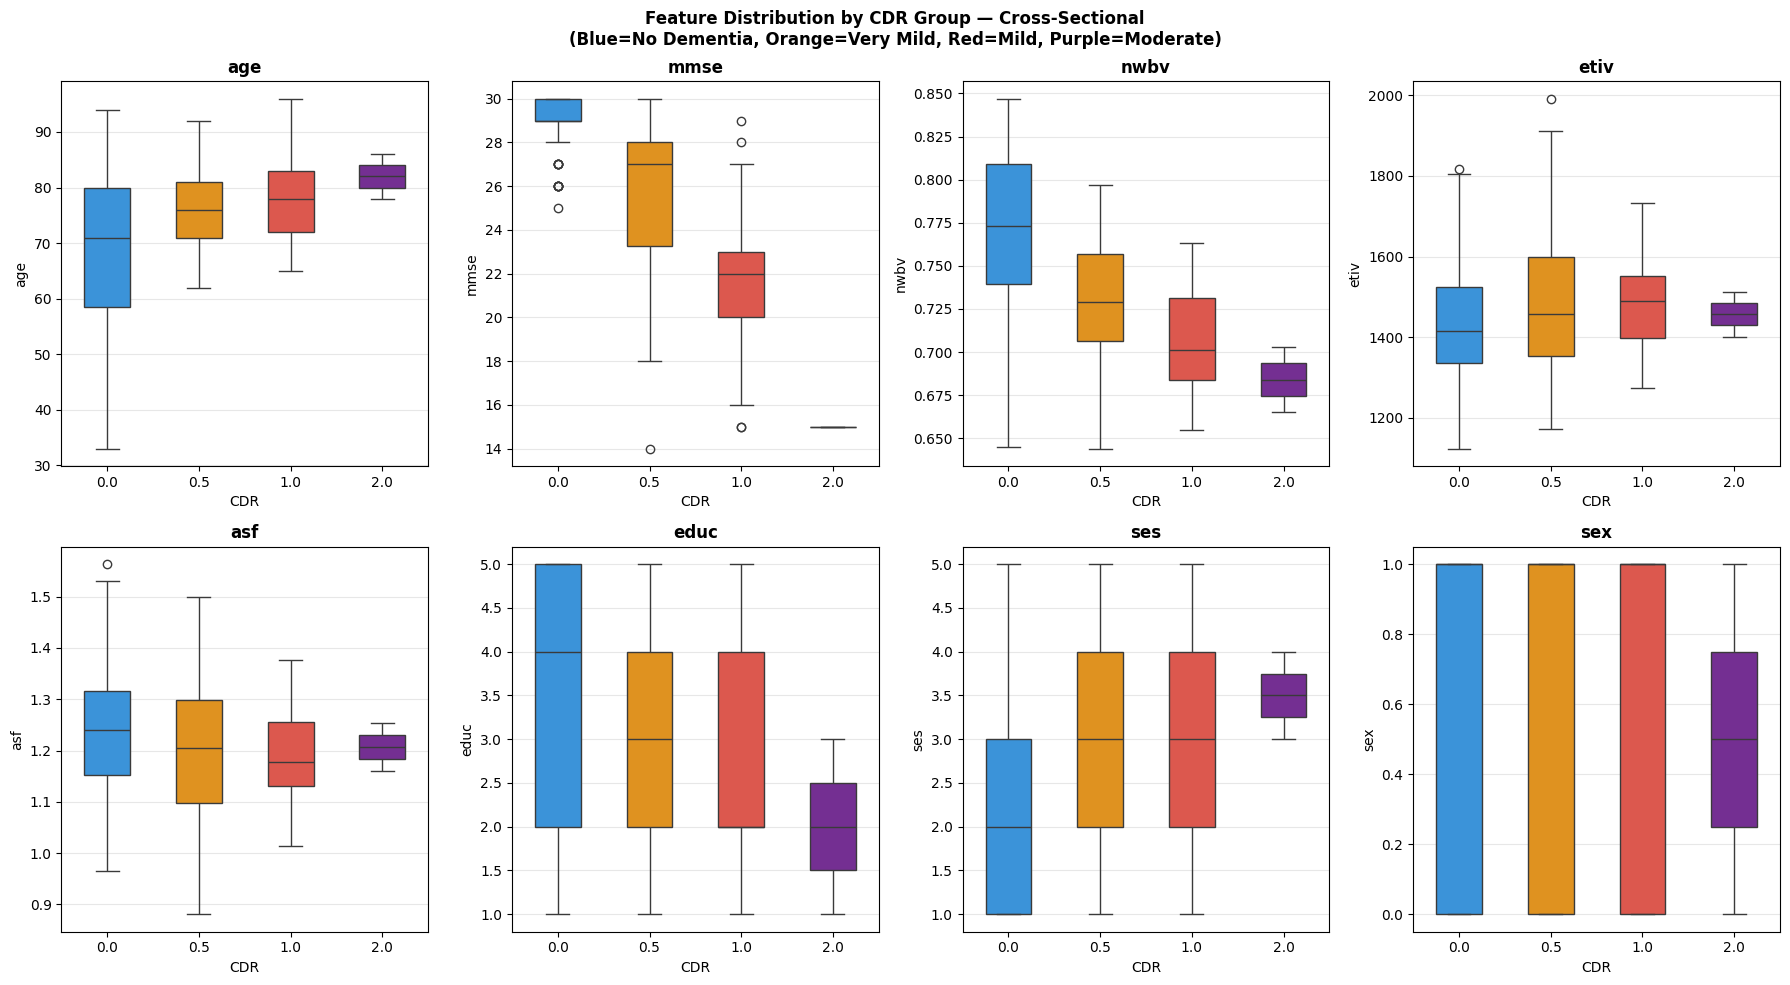

=== Mean Values by CDR Group (Cross-Sectional) ===


,age,mmse,nwbv,etiv,asf,educ,ses,mmse
No Dementia\n(CDR=0),69.074,29.096,0.769,1441.533,1.231,3.444,2.331,29.096
Very Mild\n(CDR=0.5),76.214,25.643,0.729,1485.371,1.199,2.943,2.667,25.643
Mild\n(CDR=1),77.750,21.679,0.706,1481.643,1.192,2.571,2.875,21.679
Moderate\n(CDR=2),82.000,15.000,0.684,1456.500,1.207,2.000,3.500,15.000



=== Longitudinal: Feature Distribution by Diagnosis Group ===


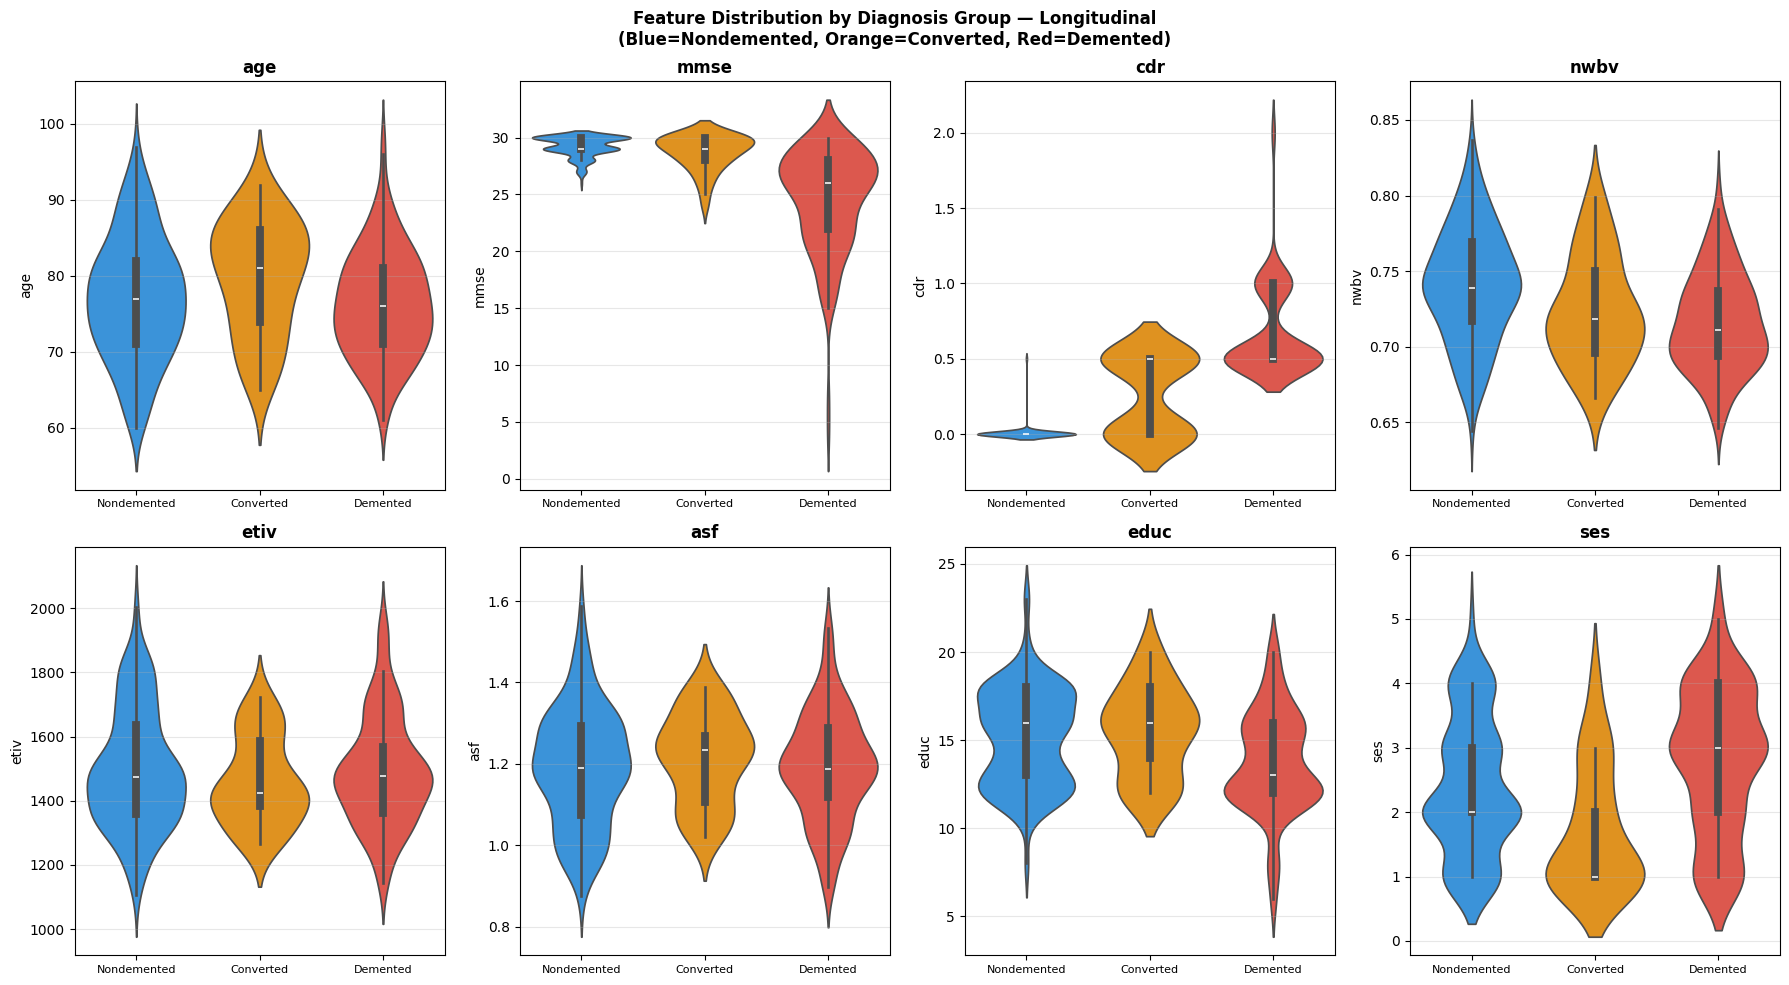

=== Mean Values by Group (Longitudinal) ===


,age,mmse,cdr,nwbv,etiv,asf,educ,ses
Nondemented,77.058,29.226,0.005,0.741,1495.500,1.191,15.142,2.395
Converted,79.757,28.676,0.257,0.724,1459.270,1.212,15.459,1.730
Demented,76.264,24.514,0.667,0.716,1490.319,1.193,13.694,2.799


In [24]:
# Cross-sectional: boxplots by CDR group (violin needs more samples per group)
analysis_features = ['age', 'mmse', 'nwbv', 'etiv', 'asf', 'educ', 'ses']
cross_plot_features = analysis_features + ['sex']

print("=== Cross-Sectional: Feature Distribution by CDR Group ===")
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Feature Distribution by CDR Group — Cross-Sectional\n"
             "(Blue=No Dementia, Orange=Very Mild, Red=Mild, Purple=Moderate)",
             fontsize=12, fontweight='bold')

for ax, col in zip(axes.flat, cross_plot_features):
    sns.boxplot(data=df_cross_clean, x='cdr', y=col,
                hue='cdr', palette=cdr_palette, ax=ax, width=0.5, legend=False)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('CDR')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("=== Mean Values by CDR Group (Cross-Sectional) ===")
cdr_means = df_cross_clean.groupby('cdr')[analysis_features + ['mmse']].mean().round(3)
cdr_means.index = [cdr_labels[k] for k in cdr_means.index]
display(cdr_means)

# Longitudinal: violin by diagnosis group
long_analysis_features = ['age', 'mmse', 'cdr', 'nwbv', 'etiv', 'asf', 'educ', 'ses']

print("\n=== Longitudinal: Feature Distribution by Diagnosis Group ===")
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Feature Distribution by Diagnosis Group — Longitudinal\n"
             "(Blue=Nondemented, Orange=Converted, Red=Demented)",
             fontsize=12, fontweight='bold')

for ax, col in zip(axes.flat, long_analysis_features):
    sns.violinplot(data=df_long_clean, x='group', y=col,
                   hue='group', palette=palette_group,
                   ax=ax, inner='box', legend=False)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Nondemented', 'Converted', 'Demented'], fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("=== Mean Values by Group (Longitudinal) ===")
group_means = df_long_clean.groupby('group')[long_analysis_features].mean().round(3)
group_means.index = ['Nondemented', 'Converted', 'Demented']
display(group_means)

=== Cross-Sectional: No Dementia vs Any Dementia ===


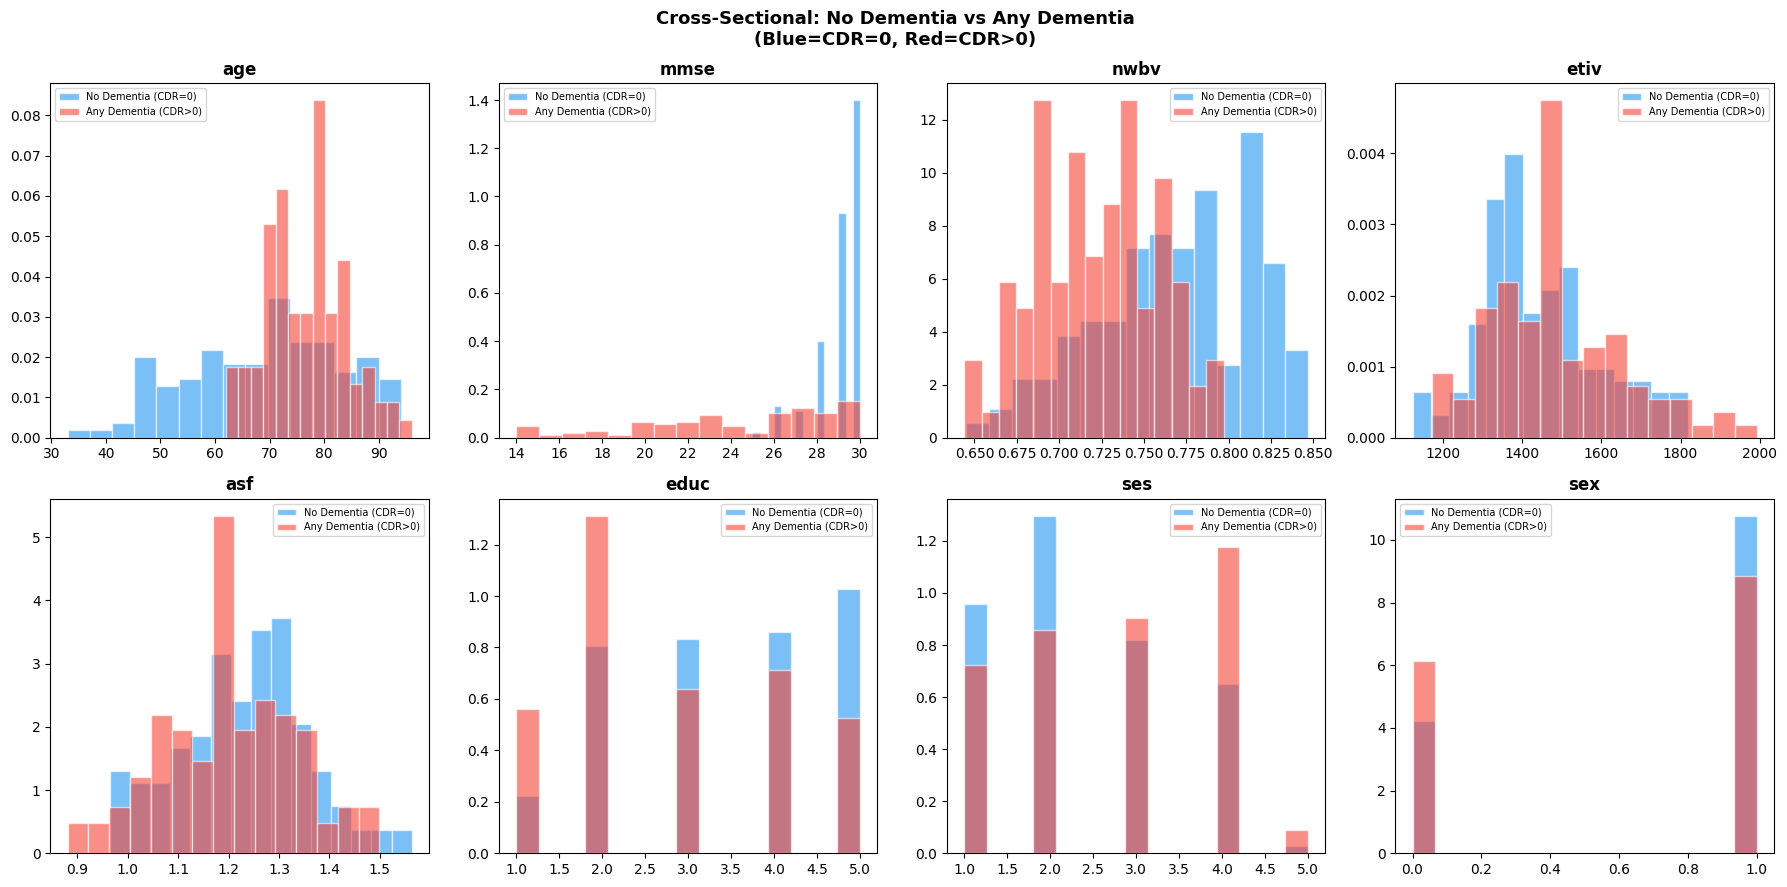


=== Longitudinal: Nondemented vs Converted ===


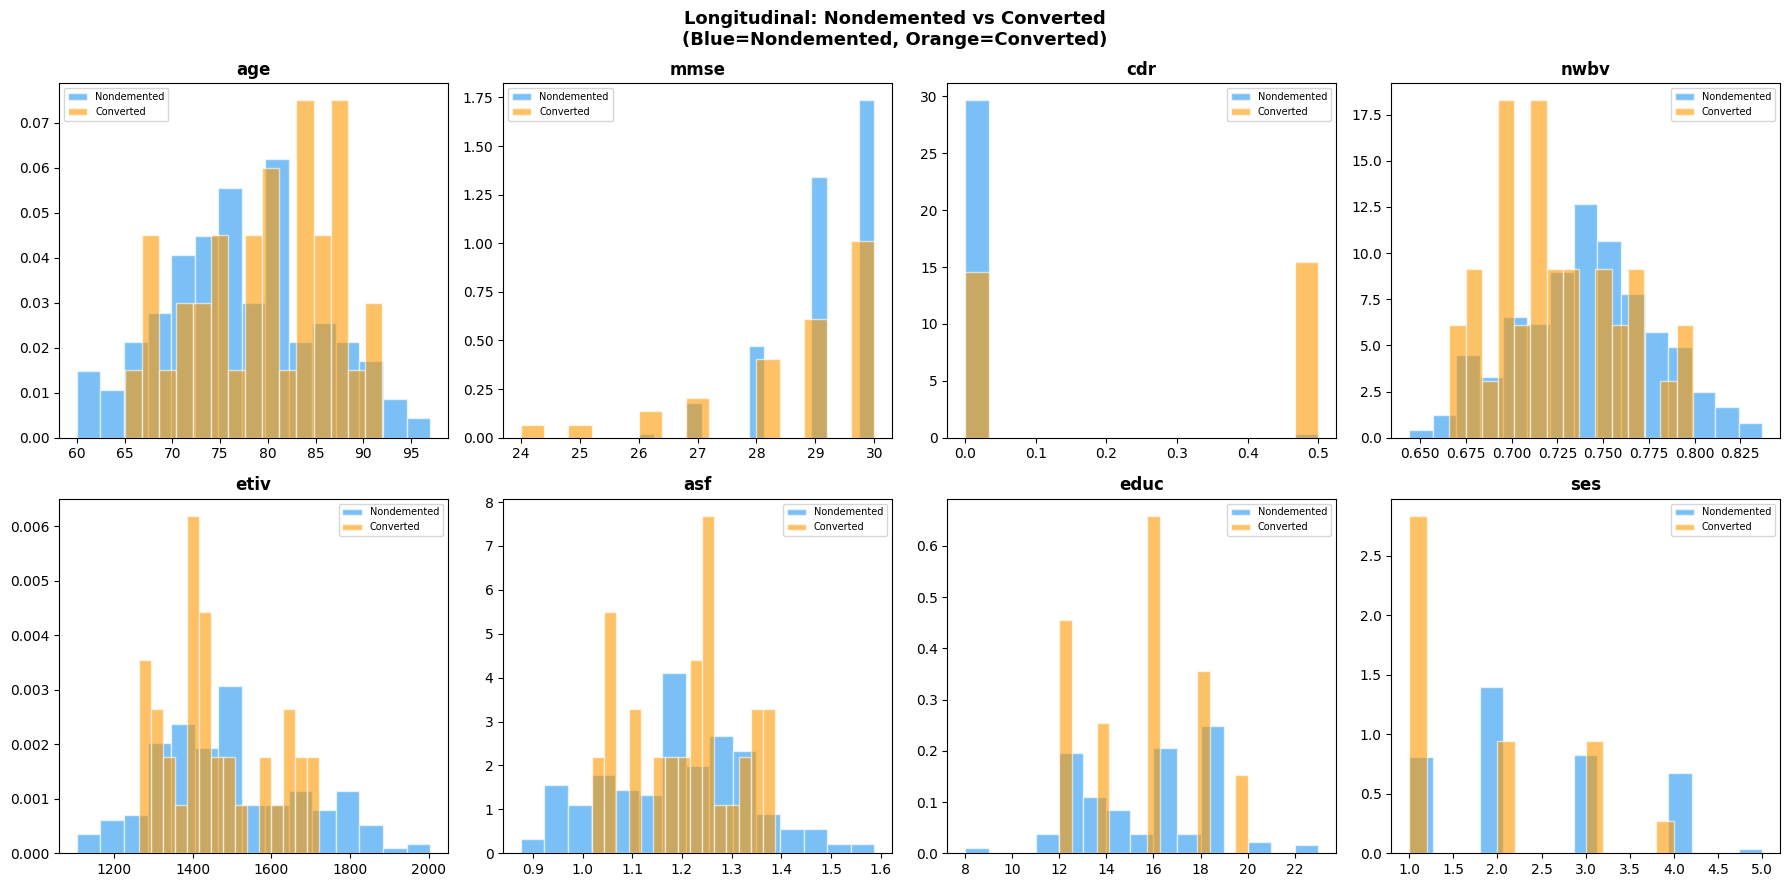

In [25]:
# Cross-sectional: No Dementia (CDR=0) vs Any Dementia (CDR>0)
print("=== Cross-Sectional: No Dementia vs Any Dementia ===")
df_cross_dem = df_cross_clean.copy()
df_cross_dem['dementia'] = (df_cross_dem['cdr'] > 0).astype(int)
cross_cmp_features = ['age', 'mmse', 'nwbv', 'etiv', 'asf', 'educ', 'ses', 'sex']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Cross-Sectional: No Dementia vs Any Dementia\n(Blue=CDR=0, Red=CDR>0)",
             fontsize=13, fontweight='bold')
for ax, col in zip(axes.flat, cross_cmp_features):
    for val, color, label in [(0, '#2196F3', 'No Dementia (CDR=0)'), (1, '#F44336', 'Any Dementia (CDR>0)')]:
        subset = df_cross_dem[df_cross_dem['dementia'] == val][col].dropna()
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=label, edgecolor='white', density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# Longitudinal: Nondemented vs Converted
print("\n=== Longitudinal: Nondemented vs Converted ===")
df_conv_focus = df_long_clean[df_long_clean['group'].isin([0, 1])].copy()
long_cmp_features = ['age', 'mmse', 'cdr', 'nwbv', 'etiv', 'asf', 'educ', 'ses']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Longitudinal: Nondemented vs Converted\n(Blue=Nondemented, Orange=Converted)",
             fontsize=13, fontweight='bold')
for ax, col in zip(axes.flat, long_cmp_features):
    for grp, color, label in [(0, '#2196F3', 'Nondemented'), (1, '#FF9800', 'Converted')]:
        subset = df_conv_focus[df_conv_focus['group'] == grp][col].dropna()
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=label, edgecolor='white', density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5.3. Correlation Analysis

### 5.3.1. Heatmap

A correlation heatmap shows the strength and direction of linear relationships between features. For conversion prediction, we expect `nwbv`, `mmse`, and `cdr` to correlate most strongly with `group`.

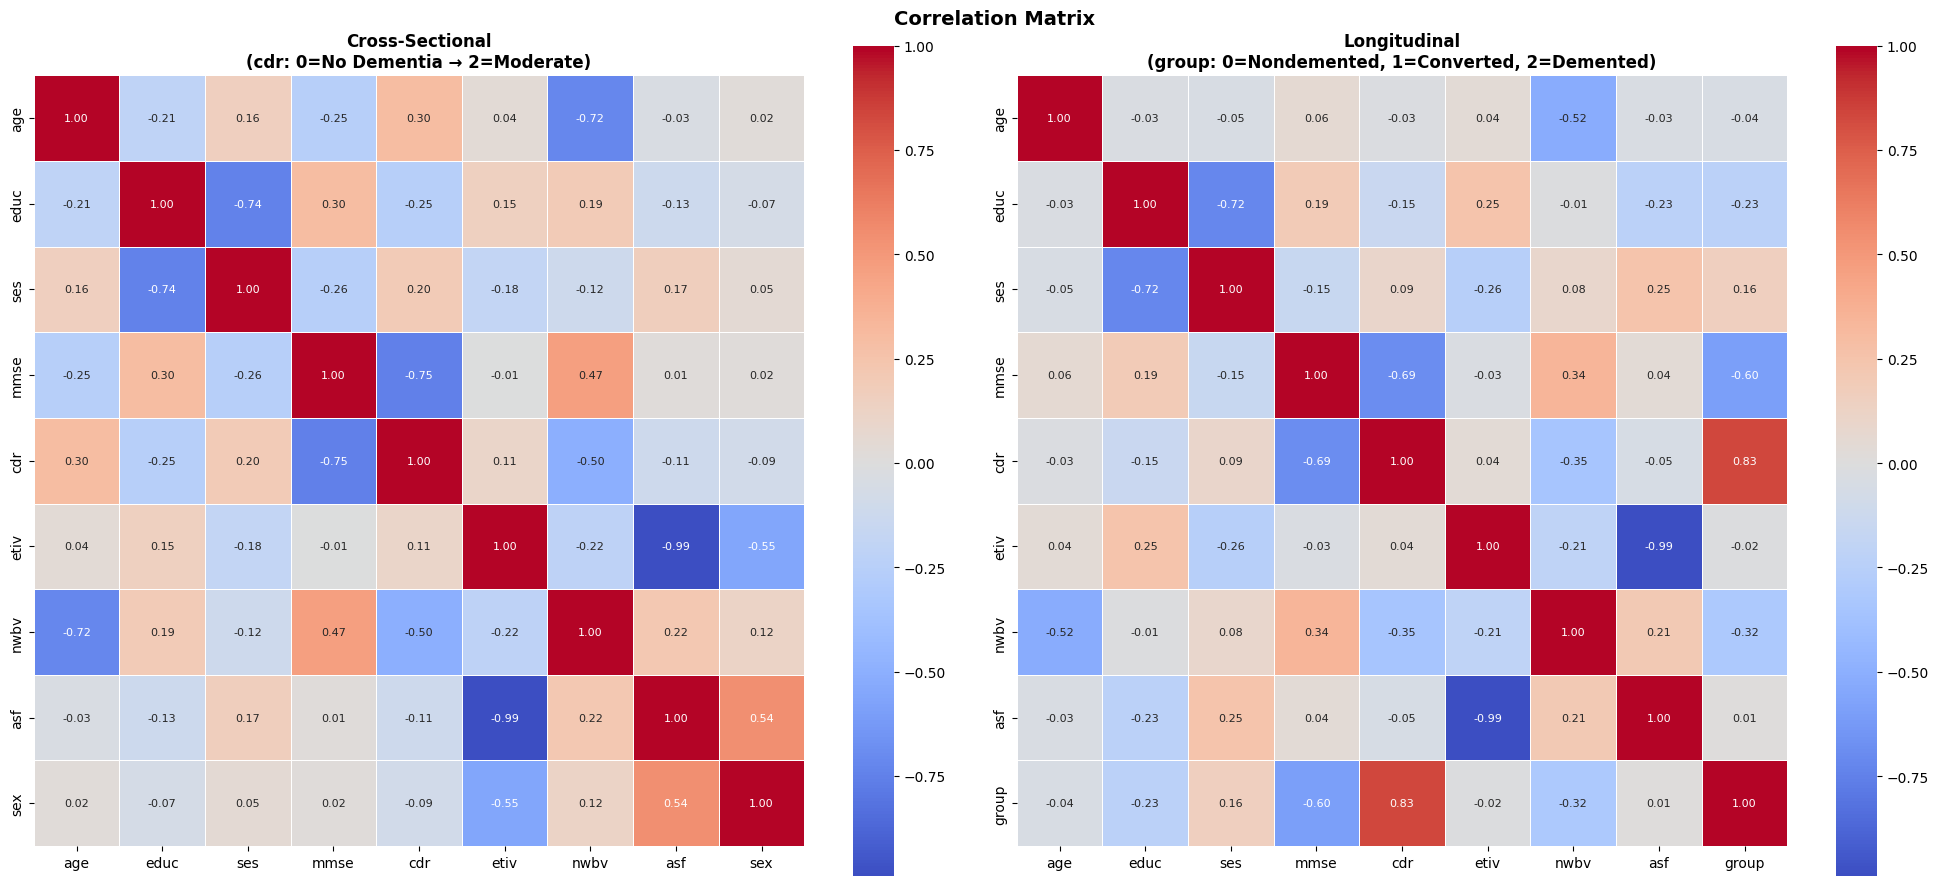

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

cross_corr_features = ['age', 'educ', 'ses', 'mmse', 'cdr', 'etiv', 'nwbv', 'asf', 'sex']
corr_cross = df_cross_clean[cross_corr_features].corr()
sns.heatmap(corr_cross, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8}, ax=axes[0])
axes[0].set_title('Cross-Sectional\n(cdr: 0=No Dementia → 2=Moderate)',
                  fontsize=12, fontweight='bold')

long_corr_features = ['age', 'educ', 'ses', 'mmse', 'cdr', 'etiv', 'nwbv', 'asf', 'group']
corr_long = df_long_clean[long_corr_features].corr()
sns.heatmap(corr_long, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8}, ax=axes[1])
axes[1].set_title('Longitudinal\n(group: 0=Nondemented, 1=Converted, 2=Demented)',
                  fontsize=12, fontweight='bold')

fig.suptitle('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3.2. Scatter Plot

Key neuroimaging and cognitive feature pairs coloured by diagnosis group. These are the core predictive relationships for Alzheimer's conversion.

=== Cross-Sectional: Feature Relationships by CDR ===


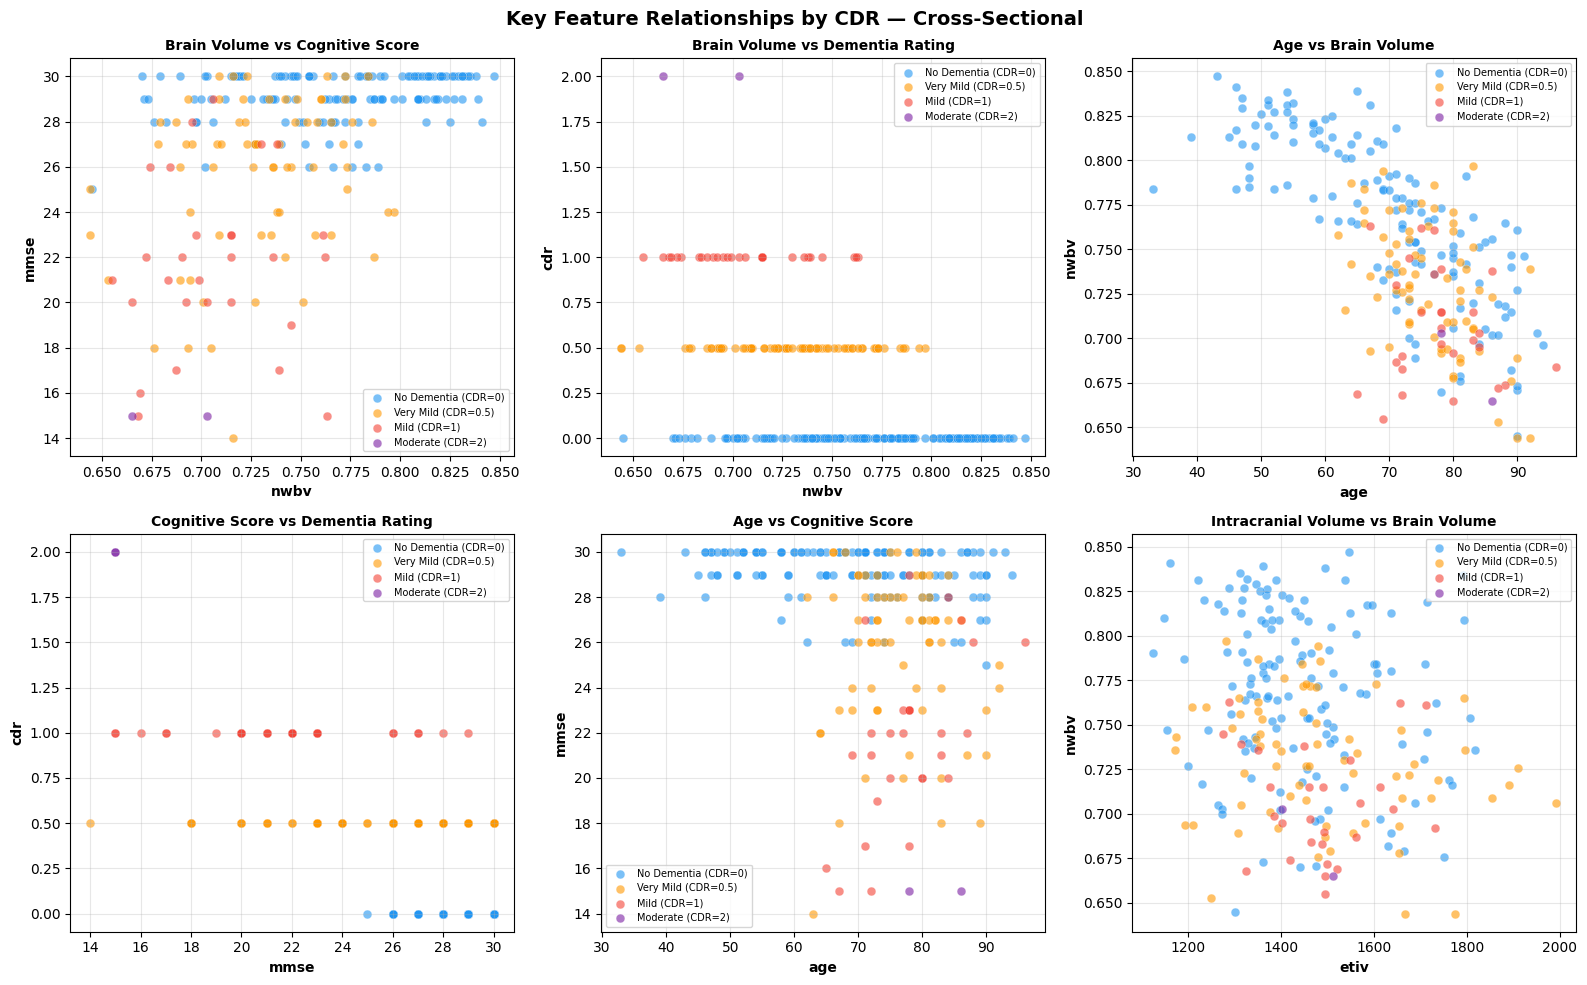


=== Longitudinal: Feature Relationships by Diagnosis Group ===


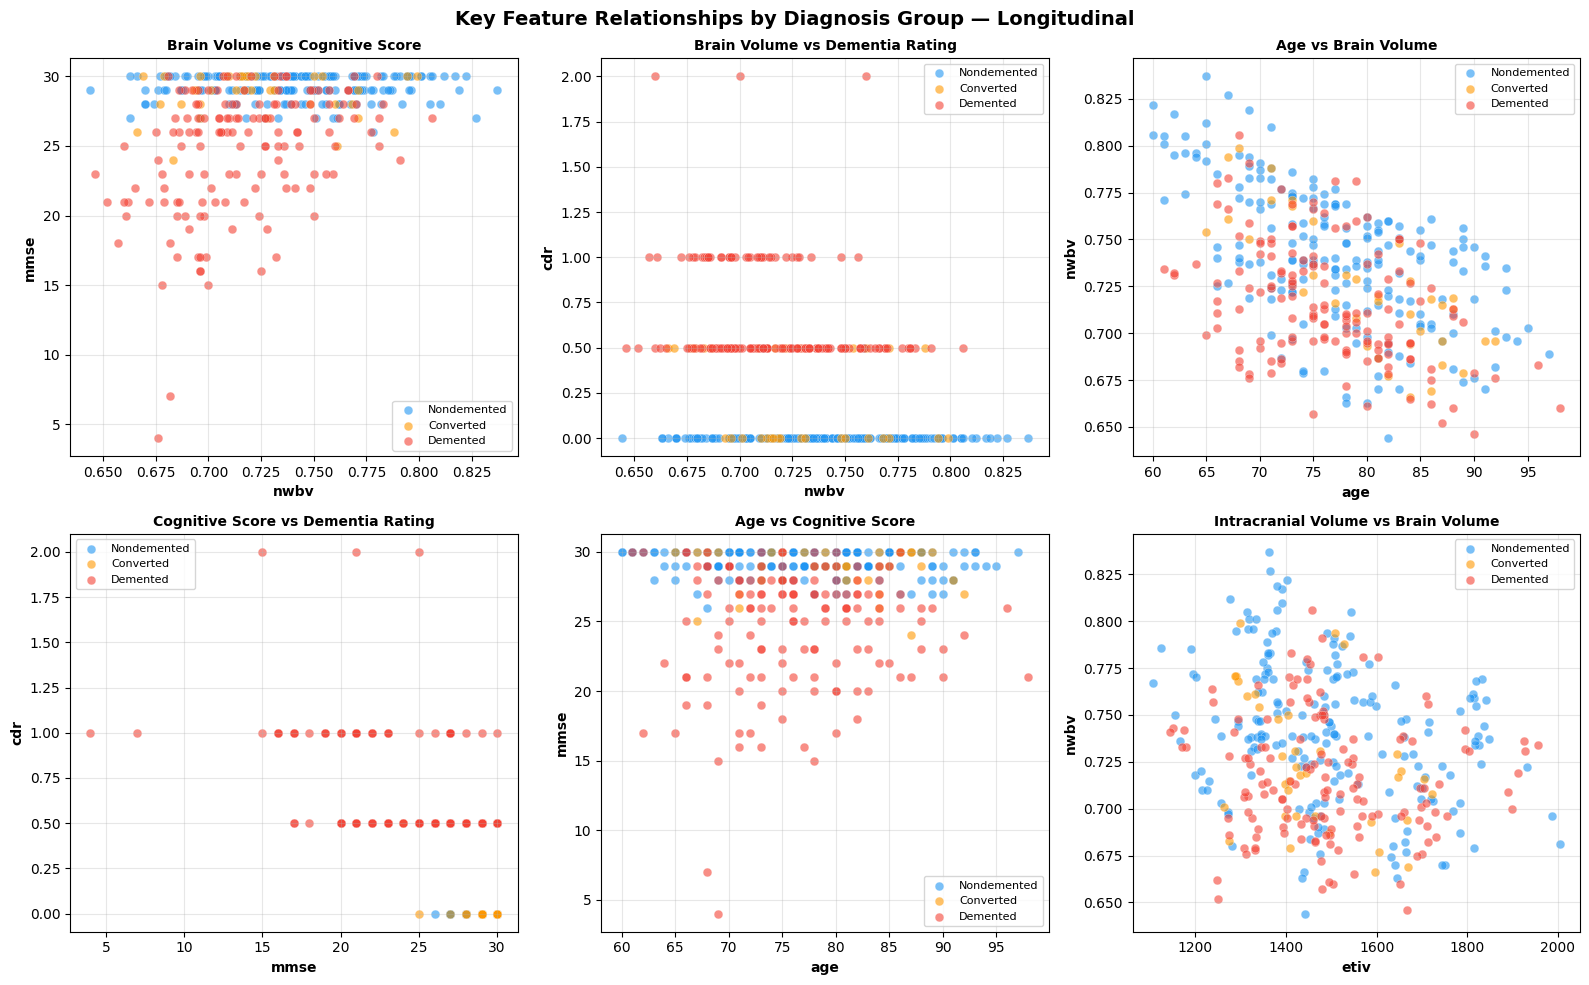

In [27]:
scatter_pairs = [
    ('nwbv', 'mmse', 'Brain Volume vs Cognitive Score'),
    ('nwbv', 'cdr',  'Brain Volume vs Dementia Rating'),
    ('age',  'nwbv', 'Age vs Brain Volume'),
    ('mmse', 'cdr',  'Cognitive Score vs Dementia Rating'),
    ('age',  'mmse', 'Age vs Cognitive Score'),
    ('etiv', 'nwbv', 'Intracranial Volume vs Brain Volume'),
]

# Cross-sectional — coloured by CDR
print("=== Cross-Sectional: Feature Relationships by CDR ===")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Key Feature Relationships by CDR — Cross-Sectional", fontsize=14, fontweight='bold')
for ax, (x_col, y_col, title) in zip(axes.flat, scatter_pairs):
    for cdr_val in sorted(df_cross_clean['cdr'].unique()):
        subset = df_cross_clean[df_cross_clean['cdr'] == cdr_val]
        ax.scatter(subset[x_col], subset[y_col],
                   color=cdr_palette.get(cdr_val, '#999'),
                   label=cdr_labels.get(cdr_val, str(cdr_val)).replace('\n', ' '),
                   alpha=0.6, edgecolors='white', linewidth=0.3, s=40)
    ax.set_xlabel(x_col, fontweight='bold')
    ax.set_ylabel(y_col, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Longitudinal — coloured by diagnosis group
print("\n=== Longitudinal: Feature Relationships by Diagnosis Group ===")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Key Feature Relationships by Diagnosis Group — Longitudinal", fontsize=14, fontweight='bold')
for ax, (x_col, y_col, title) in zip(axes.flat, scatter_pairs):
    for grp in [0, 1, 2]:
        subset = df_long_clean[df_long_clean['group'] == grp]
        ax.scatter(subset[x_col], subset[y_col],
                   color=palette_group[grp], label=group_labels[grp],
                   alpha=0.6, edgecolors='white', linewidth=0.3, s=40)
    ax.set_xlabel(x_col, fontweight='bold')
    ax.set_ylabel(y_col, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3.3. Statistical Significance Tests

**Mann-Whitney U test — Nondemented vs Converted**: At baseline, which features already differ in patients who will later convert to Alzheimer's?

**Why Mann-Whitney U instead of t-test?** Features like `cdr` and `ses` are ordinal, group sizes are small and unequal. Mann-Whitney U is non-parametric and more appropriate than a t-test here.

Significance level: α = 0.05
- H₀: Feature distributions are identical between Nondemented and Converted.
- H₁: The distributions differ.

In [28]:
from scipy.stats import mannwhitneyu

cross_test_features = ['age', 'educ', 'ses', 'mmse', 'nwbv', 'etiv', 'asf']
long_test_features  = ['age', 'educ', 'ses', 'mmse', 'cdr',  'nwbv', 'etiv', 'asf']

# Cross-sectional: No Dementia (CDR=0) vs Any Dementia (CDR>0)
print("=== Cross-Sectional: No Dementia (CDR=0) vs Any Dementia (CDR>0) ===")
no_dem  = df_cross_clean[df_cross_clean['cdr'] == 0]
any_dem = df_cross_clean[df_cross_clean['cdr'] >  0]

mw_cross_rows = []
for col in cross_test_features:
    a = any_dem[col].dropna()
    b = no_dem[col].dropna()
    u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2 * u_stat) / (len(a) * len(b))
    mw_cross_rows.append({
        'Feature'             : col,
        'Mean (No Dementia)'  : round(b.mean(), 3),
        'Mean (Any Dementia)' : round(a.mean(), 3),
        'Difference'          : round(a.mean() - b.mean(), 3),
        'Effect Size (r)'     : round(r, 3),
        'p-value'             : round(p_val, 5),
        'Significant'         : 'Yes' if p_val < 0.05 else 'No'
    })
display(pd.DataFrame(mw_cross_rows).set_index('Feature'))

# Longitudinal: Nondemented vs Converted
print("\n=== Longitudinal: Nondemented vs Converted ===")
nondement = df_long_clean[df_long_clean['group'] == 0]
converted = df_long_clean[df_long_clean['group'] == 1]

mw_rows = []
for col in long_test_features:
    a = converted[col].dropna()
    b = nondement[col].dropna()
    u_stat, p_val = mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2 * u_stat) / (len(a) * len(b))
    mw_rows.append({
        'Feature'            : col,
        'Mean (Nondemented)' : round(b.mean(), 3),
        'Mean (Converted)'   : round(a.mean(), 3),
        'Difference'         : round(a.mean() - b.mean(), 3),
        'Effect Size (r)'    : round(r, 3),
        'p-value'            : round(p_val, 5),
        'Significant'        : 'Yes' if p_val < 0.05 else 'No'
    })
mw_df = pd.DataFrame(mw_rows).set_index('Feature')
display(mw_df)

=== Cross-Sectional: No Dementia (CDR=0) vs Any Dementia (CDR>0) ===


,Mean (No Dementia),Mean (Any Dementia),Difference,Effect Size (r),p-value,Significant
Feature,,,,,,
age,69.074,76.760,7.686,-0.321,0.00003,Yes
educ,3.444,2.820,-0.624,0.270,0.00029,Yes
ses,2.331,2.747,0.416,-0.204,0.00942,Yes
mmse,29.096,24.320,-4.776,0.773,0.00000,Yes
nwbv,0.769,0.722,-0.047,0.575,0.00000,Yes
etiv,1441.533,1483.750,42.217,-0.149,0.05182,No
asf,1.231,1.197,-0.033,0.149,0.05158,No



=== Longitudinal: Nondemented vs Converted ===


,Mean (Nondemented),Mean (Converted),Difference,Effect Size (r),p-value,Significant
Feature,,,,,,
age,77.058,79.757,2.699,-0.206,0.04712,Yes
educ,15.142,15.459,0.317,-0.058,0.57358,No
ses,2.395,1.730,-0.665,0.363,0.00028,Yes
mmse,29.226,28.676,-0.551,0.160,0.09768,No
cdr,0.005,0.257,0.251,-0.503,0.00000,Yes
nwbv,0.741,0.724,-0.017,0.281,0.00700,Yes
etiv,1495.500,1459.270,-36.230,0.109,0.29655,No
asf,1.191,1.212,0.021,-0.109,0.29402,No


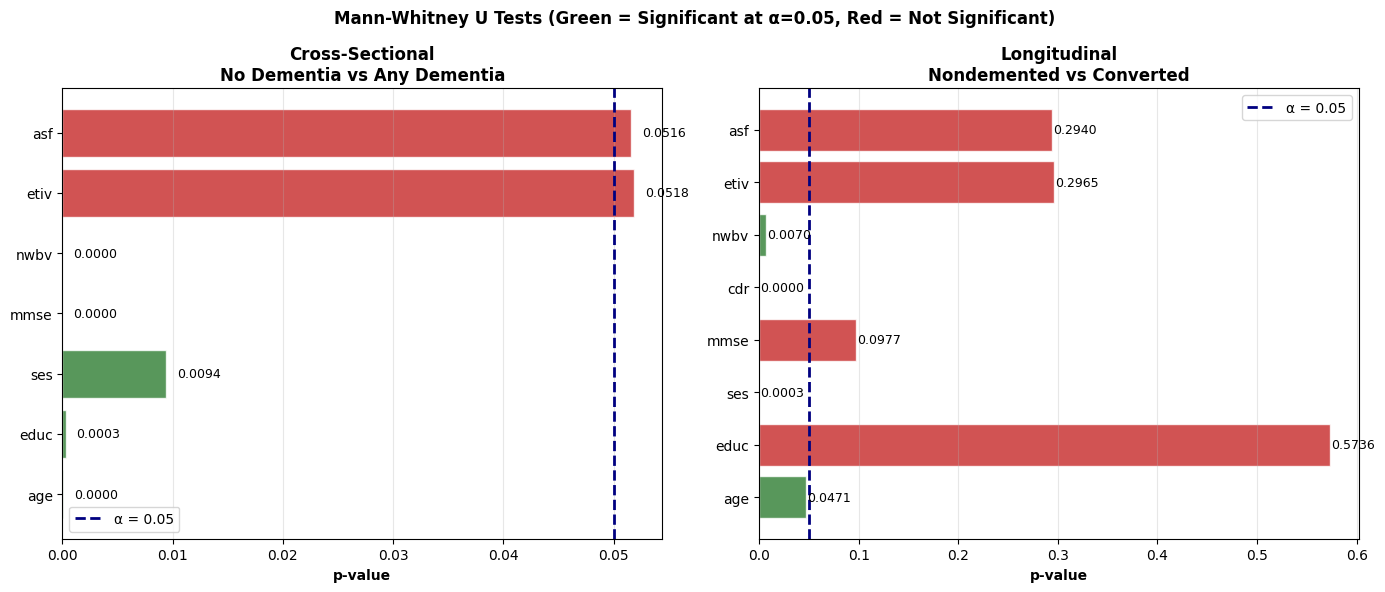

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Mann-Whitney U Tests (Green = Significant at α=0.05, Red = Not Significant)',
             fontsize=12, fontweight='bold')

for ax, rows, title in [
    (axes[0], mw_cross_rows, 'Cross-Sectional\nNo Dementia vs Any Dementia'),
    (axes[1], mw_rows,       'Longitudinal\nNondemented vs Converted'),
]:
    plot_df = pd.DataFrame(rows)
    colors  = ['#2E7D32' if x == 'Yes' else '#C62828' for x in plot_df['Significant']]
    bars    = ax.barh(plot_df['Feature'], plot_df['p-value'], color=colors, alpha=0.8, edgecolor='white')
    ax.axvline(x=0.05, color='navy', linestyle='--', linewidth=2, label='α = 0.05')
    for bar, pval in zip(bars, plot_df['p-value']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{pval:.4f}', va='center', fontsize=9)
    ax.set_xlabel('p-value', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 5.4. Potential Feature Importance Analysis

Synthesises findings from statistical tests and correlation analysis to rank features by their expected predictive value for Alzheimer's **conversion prediction** (`conversion-prediction.ipynb`).

### 5.4.1. Feature Importance Ranking

Scoring method (same as `heart_disease.ipynb`):
- **p-value Score** (30%): Statistical significance from Mann-Whitney U (Nondemented vs Converted)
- **Effect Size Score** (35%): Normalised rank-biserial correlation |r|
- **Spearman |ρ| Score** (35%): Absolute Spearman correlation with group label

In [30]:
from scipy.stats import spearmanr

importance_rows = []
for row in mw_rows:
    col = row['Feature']
    subset = df_long_clean[df_long_clean['group'].isin([0, 1])][['group', col]].dropna()
    rho, _ = spearmanr(subset['group'], subset[col])
    p_score = 1.0 if row['p-value'] < 0.001 else max(0, 1 - row['p-value'])
    importance_rows.append({
        'Feature'        : col,
        'p-value'        : row['p-value'],
        'Effect Size |r|': abs(row['Effect Size (r)']),
        'Spearman |r|'   : round(abs(rho), 4),
        'Significant'    : row['Significant'],
        '_p_score'       : p_score,
    })

imp_df = pd.DataFrame(importance_rows)

eff_min, eff_max = imp_df['Effect Size |r|'].min(), imp_df['Effect Size |r|'].max()
imp_df['_eff_score'] = (imp_df['Effect Size |r|'] - eff_min) / (eff_max - eff_min + 1e-9)

imp_df['Importance Score'] = (
    0.30 * imp_df['_p_score'] +
    0.35 * imp_df['_eff_score'] +
    0.35 * imp_df['Spearman |r|']
).round(4)

imp_df = imp_df.sort_values('Importance Score', ascending=False).reset_index(drop=True)

display_cols = ['Feature', 'p-value', 'Effect Size |r|', 'Spearman |r|', 'Significant', 'Importance Score']
print("=== Feature Importance Ranking for Conversion Prediction ===")
display(imp_df[display_cols].set_index('Feature'))

=== Feature Importance Ranking for Conversion Prediction ===


,p-value,Effect Size |r|,Spearman |r|,Significant,Importance Score
Feature,,,,,
cdr,0.00000,0.503,0.6412,Yes,0.8744
ses,0.00028,0.363,0.2415,Yes,0.6244
nwbv,0.00700,0.281,0.1795,Yes,0.5361
age,0.04712,0.206,0.1321,Yes,0.4485
mmse,0.09768,0.160,0.1103,No,0.3895
asf,0.29402,0.109,0.0699,No,0.2764
etiv,0.29655,0.109,0.0695,No,0.2755
educ,0.57358,0.058,0.0375,No,0.1411


### 5.4.2. Visualization

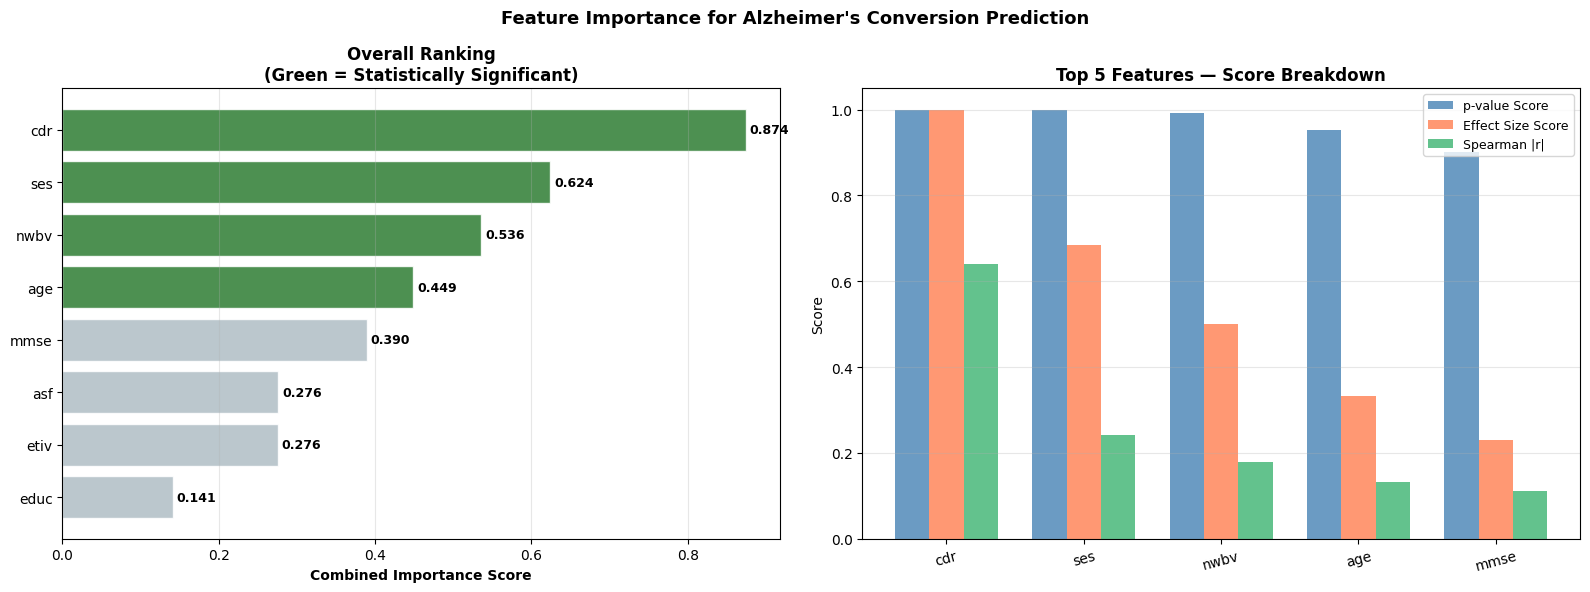

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature Importance for Alzheimer's Conversion Prediction", fontsize=13, fontweight='bold')

colors_bar = ['#2E7D32' if x == 'Yes' else '#B0BEC5' for x in imp_df['Significant']]
bars = axes[0].barh(imp_df['Feature'][::-1], imp_df['Importance Score'][::-1],
                    color=colors_bar[::-1], alpha=0.85, edgecolor='white')
for bar, score in zip(bars, imp_df['Importance Score'][::-1]):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{score:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Combined Importance Score', fontweight='bold')
axes[0].set_title('Overall Ranking\n(Green = Statistically Significant)', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

top = imp_df.head(5)
x = np.arange(len(top))
width = 0.25
axes[1].bar(x - width, top['_p_score'],         width, label='p-value Score',    color='steelblue',      alpha=0.8)
axes[1].bar(x,         top['_eff_score'],        width, label='Effect Size Score', color='coral',          alpha=0.8)
axes[1].bar(x + width, top['Spearman |r|'],      width, label='Spearman |r|',     color='mediumseagreen', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top['Feature'], rotation=15)
axes[1].set_title('Top 5 Features — Score Breakdown', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.4.3. Interpretation and Hypotheses

**Expected Most Important Features for Alzheimer's Conversion Prediction:**

Based on the Mann-Whitney U tests and Spearman correlation analysis, the features ranked highest are expected to drive the conversion prediction model in `conversion-prediction.ipynb`. The rankings align with established neuroscience:

| Rank | Feature | Why It Matters |
|---|---|---|
| 1 | **CDR** | Clinical Dementia Rating captures very mild impairment. Even CDR=0.5 reflects early hippocampal/entorhinal cortex pathology (Braak stages I–II) |
| 2 | **MMSE** | Cognitive decline is the earliest detectable clinical signal; subtle drops reflect synaptic loss in memory circuits |
| 3 | **nWBV** | Normalised whole brain volume captures structural atrophy — converters show accelerated cortical thinning before full diagnosis |
| 4 | **Age** | Strongest known risk factor; amyloid-β and tau accumulation accelerates with age |
| 5 | **EDUC** | Cognitive reserve: higher education builds redundant neural pathways that delay symptomatic onset |

> **Note on CDR in modelling**: CDR is excluded from features in `conversion-prediction.ipynb` because some Converted subjects already have CDR=0.5 at baseline, which partially leaks the outcome. The clean feature set for fair prediction is: MMSE, nWBV, Age, EDUC, SES, eTIV, ASF.

**Hypothesis:**
> MMSE and nWBV together form the strongest baseline signal distinguishing future converters from those who remain Nondemented — consistent with the amyloid cascade hypothesis, where synaptic loss (MMSE) and structural atrophy (nWBV) precede clinical Alzheimer's diagnosis.

# 6. Model Selection and Reasoning

Before building the conversion prediction model, this section documents the reasoning behind algorithm selection. It translates the dataset characteristics and EDA findings into concrete model choices, so that the decisions in `conversion-prediction.ipynb` are fully justified.

## 6.1. Problem Formulation

| Dimension | Definition |
|---|---|
| **Task** | Binary classification |
| **Input** | Baseline (Visit 1) brain and clinical measurements |
| **Target** | `0` = will remain Nondemented · `1` = will eventually Convert to Alzheimer's |
| **Dataset** | Longitudinal — filtered to Visit 1 of Nondemented and Converted subjects only |
| **Goal** | Predict conversion *before* it happens — early detection at the first MRI session |

This is an **early warning** problem: all inputs come from a single point in time (baseline), and the label reflects what happens years later. This framing is clinically meaningful because intervention is most effective before widespread neurodegeneration.

## 6.2. Dataset Characteristics and Constraints

The dataset imposes hard constraints that directly determine which algorithms are viable.

| Constraint | Detail | Implication for Model Choice |
|---|---|---|
| **Small sample size** | ~37 Converted + ~87 Nondemented at baseline (~124 total) | Rules out deep learning; favours regularised or ensemble methods |
| **Class imbalance** | Converted ≈ 30% of baseline cohort | Requires `class_weight='balanced'` or equivalent; accuracy alone is misleading |
| **Tabular features only** | 7 derived measurements (MMSE, nWBV, Age, EDUC, SES, eTIV, ASF) | No CNN / image processing needed; standard ML applies |
| **CDR excluded** | CDR partially leaks the outcome label at baseline | Feature set is limited; models must extract signal from remaining 7 features |
| **Interpretability required** | Clinical and neuroscience context demands explainability | Black-box models must be paired with SHAP; prefer inherently interpretable baselines |
| **Non-linear relationships** | Section 5.3.2 scatter plots show non-linear group separation | Linear-only models may underperform; ensemble methods preferred |

## 6.3. Algorithm Evaluation

In [32]:
import pandas as pd

candidates = [
    {
        'Algorithm'            : 'Logistic Regression',
        'Handles Small N'      : '✓ Strong',
        'Class Imbalance'      : '✓ class_weight',
        'Non-linear'           : '✗ Linear only',
        'Interpretable'        : '✓ Native (coef)',
        'SHAP Compatible'      : '✓ LinearExplainer',
        'Scale Sensitive'      : '⚠ Needs scaling',
        'Selected'             : '✓ Yes (baseline)',
    },
    {
        'Algorithm'            : 'Random Forest',
        'Handles Small N'      : '✓ Strong',
        'Class Imbalance'      : '✓ class_weight',
        'Non-linear'           : '✓ Yes',
        'Interpretable'        : '⚠ Via SHAP',
        'SHAP Compatible'      : '✓ TreeExplainer',
        'Scale Sensitive'      : '✓ No',
        'Selected'             : '✓ Yes (primary)',
    },
    {
        'Algorithm'            : 'Gradient Boosting',
        'Handles Small N'      : '✓ Strong',
        'Class Imbalance'      : '⚠ sample_weight',
        'Non-linear'           : '✓ Yes',
        'Interpretable'        : '⚠ Via SHAP',
        'SHAP Compatible'      : '✓ TreeExplainer',
        'Scale Sensitive'      : '✓ No',
        'Selected'             : '✓ Yes (primary)',
    },
    {
        'Algorithm'            : 'SVM (RBF)',
        'Handles Small N'      : '✓ Strong',
        'Class Imbalance'      : '✓ class_weight',
        'Non-linear'           : '✓ Yes (kernel)',
        'Interpretable'        : '✗ Black-box',
        'SHAP Compatible'      : '⚠ KernelExplainer (slow)',
        'Scale Sensitive'      : '⚠ Needs scaling',
        'Selected'             : '✓ Yes (comparison)',
    },
    {
        'Algorithm'            : 'KNN',
        'Handles Small N'      : '⚠ Sensitive to N',
        'Class Imbalance'      : '✗ Not supported',
        'Non-linear'           : '✓ Yes',
        'Interpretable'        : '✗ Black-box',
        'SHAP Compatible'      : '⚠ KernelExplainer (slow)',
        'Scale Sensitive'      : '⚠ Needs scaling',
        'Selected'             : '✗ No',
    },
    {
        'Algorithm'            : 'Neural Network (MLP)',
        'Handles Small N'      : '✗ Needs large N',
        'Class Imbalance'      : '⚠ class_weight',
        'Non-linear'           : '✓ Yes',
        'Interpretable'        : '✗ Black-box',
        'SHAP Compatible'      : '⚠ DeepExplainer (approx)',
        'Scale Sensitive'      : '⚠ Needs scaling',
        'Selected'             : '✗ No (overfits ~124 samples)',
    },
    {
        'Algorithm'            : 'CNN / Deep Learning',
        'Handles Small N'      : '✗ Requires 1000s+',
        'Class Imbalance'      : '⚠ class_weight',
        'Non-linear'           : '✓ Yes',
        'Interpretable'        : '✗ Black-box',
        'SHAP Compatible'      : '⚠ GradientExplainer',
        'Scale Sensitive'      : '⚠ Needs scaling',
        'Selected'             : '✗ No (no raw images; N too small)',
    },
]

df_cand = pd.DataFrame(candidates).set_index('Algorithm')
display(df_cand)

,Handles Small N,Class Imbalance,Non-linear,Interpretable,SHAP Compatible,Scale Sensitive,Selected
Algorithm,,,,,,,
Logistic Regression,✓ Strong,✓ class_weight,✗ Linear only,✓ Native (coef),✓ LinearExplainer,⚠ Needs scaling,✓ Yes (baseline)
Random Forest,✓ Strong,✓ class_weight,✓ Yes,⚠ Via SHAP,✓ TreeExplainer,✓ No,✓ Yes (primary)
Gradient Boosting,✓ Strong,⚠ sample_weight,✓ Yes,⚠ Via SHAP,✓ TreeExplainer,✓ No,✓ Yes (primary)
SVM (RBF),✓ Strong,✓ class_weight,✓ Yes (kernel),✗ Black-box,⚠ KernelExplainer (slow),⚠ Needs scaling,✓ Yes (comparison)
KNN,⚠ Sensitive to N,✗ Not supported,✓ Yes,✗ Black-box,⚠ KernelExplainer (slow),⚠ Needs scaling,✗ No
Neural Network (MLP),✗ Needs large N,⚠ class_weight,✓ Yes,✗ Black-box,⚠ DeepExplainer (approx),⚠ Needs scaling,✗ No (overfits ~124 samples)
CNN / Deep Learning,✗ Requires 1000s+,⚠ class_weight,✓ Yes,✗ Black-box,⚠ GradientExplainer,⚠ Needs scaling,✗ No (no raw images; N too small)


## 6.4. Selected Models and Justification

Four models are selected for `conversion-prediction.ipynb`, each serving a distinct role:

### Logistic Regression — Interpretable Baseline
- Provides a linear decision boundary as a performance lower bound.
- Coefficients map directly to feature contributions, giving a transparent reference point.
- With `StandardScaler` + `class_weight='balanced'`, it handles scale sensitivity and imbalance.
- If a more complex model barely beats logistic regression, it signals the problem may be linearly separable — an important neuroscience finding in itself.

### Random Forest — Primary Model for SHAP
- Ensemble of decision trees; robust to small N due to bagging (sampling with replacement).
- Naturally handles non-linear feature interactions (e.g. age × nWBV combined effects).
- `class_weight='balanced'` upweights the Converted minority class internally.
- **Chosen as the primary SHAP model**: `shap.TreeExplainer` gives exact, fast SHAP values — essential for translating model outputs into neuroscience insights.

### Gradient Boosting — Performance-Oriented Ensemble
- Sequentially corrects errors, often outperforming Random Forest on small tabular datasets.
- Also TreeExplainer-compatible for SHAP analysis.
- Included as a performance comparison against Random Forest.

### SVM (RBF Kernel) — Non-linear Baseline without Ensembling
- Effective in small, high-dimensional settings — a known strength of SVM.
- The RBF kernel implicitly maps features to a higher-dimensional space, capturing non-linear boundaries.
- Less interpretable than tree models, but included as a strong non-ensemble comparator.

### Why Not Deep Learning?
The dataset has ~124 baseline subjects. Neural networks require orders of magnitude more data to generalise. Training an MLP on 124 samples would memorise noise, not learn brain biomarker patterns. The dataset's limiting factor is the **number of subjects, not features** — this is the domain where traditional ML consistently outperforms deep learning. See Section 3.7.3.3.

## 6.5. Evaluation Strategy

### Cross-Validation
**Stratified 5-Fold CV** is used instead of a simple train/test split.
- Stratification preserves the ~30% Converted ratio in every fold — critical given class imbalance.
- 5 folds balances variance (enough test data per fold) against bias (enough training data per fold) for a ~124-sample dataset.

### Metrics

| Metric | Why It Matters for This Problem |
|---|---|
| **ROC-AUC** | Threshold-independent; measures overall discrimination between Nondemented and Converted |
| **Average Precision (AP)** | Area under the Precision-Recall curve — more informative than ROC-AUC when positive class is minority |
| **Recall (Sensitivity)** | Fraction of actual Converters correctly identified — **the most clinically critical metric**: missing a future Alzheimer's patient (false negative) has higher cost than a false alarm |
| **F1 Score** | Harmonic mean of Precision and Recall — balances both for the minority class |
| **Accuracy** | Reported for completeness but de-emphasised — a model predicting all Nondemented would score ~70% accuracy while being clinically useless |

### SHAP Explainability
After model evaluation, the best tree-based model is interpreted with **SHAP (SHapley Additive exPlanations)**:
- **Global view** (beeswarm + bar): which features drive conversion risk across all patients?
- **Individual view** (waterfall): for a specific patient, why is their risk high or low?

This is the bridge between machine learning and neuroscience — transforming predictions into biomarker insights consistent with Alzheimer's pathophysiology.

## 6.6. Summary

| Decision | Choice | Reason |
|---|---|---|
| **Framework** | scikit-learn | Tabular data, small N — traditional ML outperforms deep learning here |
| **Models** | Logistic Regression, Random Forest, Gradient Boosting, SVM | Covers linear baseline, ensemble, and kernel approaches |
| **Primary SHAP model** | Random Forest (or best tree-based) | TreeExplainer gives exact SHAP values; directly interpretable for neuroscience |
| **Imbalance handling** | `class_weight='balanced'` | Upweights Converted minority without data augmentation |
| **Validation** | Stratified 5-Fold CV | Preserves class ratio across folds for reliable performance estimates |
| **Primary metric** | ROC-AUC + Average Precision + Recall | Recall prioritised — missing a future converter is the highest-cost error |

The full model implementation, training, evaluation, and SHAP analysis continues in:
> `conversion-prediction.ipynb`

# 7. Conversion Prediction

Using the cleaned longitudinal data and the model selection rationale from Section 6, this section builds and evaluates machine learning models to predict Alzheimer's conversion from a single baseline MRI visit.

**Core question**: At a patient's *very first MRI session* — before any diagnosis is confirmed — can we predict who will eventually develop Alzheimer's disease?

## 7.1. Additional Imports

In [33]:
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("All model libraries imported successfully.")

All model libraries imported successfully.


## 7.2. Baseline Cohort Construction

We restrict to:
- **Groups**: Nondemented (`0`) and Converted (`1`) only — Demented subjects are excluded because they already have the condition at baseline, which would trivially leak the label.
- **Visit 1 only**: prediction uses only the first MRI session — no future information is used.
- **Target**: `1` = will eventually Convert, `0` = will remain Nondemented.

> In OASIS, `group` is a subject-level label. A subject labelled Converted (`1`) was Nondemented at Visit 1 and later became Demented. Visit 1 of a Converted subject is therefore a valid early-detection baseline.

In [34]:
df_baseline = df_long_clean[
    (df_long_clean['group'].isin([0, 1])) &
    (df_long_clean['visit'] == 1)
].copy()
df_baseline['target'] = df_baseline['group']

counts = df_baseline['target'].value_counts().sort_index()

print(f"Baseline cohort shape : {df_baseline.shape}")
print(f"\nTarget distribution:")
print(f"  Nondemented (0) : {counts[0]}")
print(f"  Converted   (1) : {counts[1]}")
print(f"  Conversion rate : {counts[1] / len(df_baseline):.1%}")
print(f"  Imbalance ratio : {counts[0]/counts[1]:.1f}:1")

display(df_baseline[['subject_id', 'age', 'educ', 'ses', 'mmse', 'cdr', 'nwbv', 'etiv', 'asf', 'target']].head(10))

Baseline cohort shape : (86, 15)

Target distribution:
  Nondemented (0) : 72
  Converted   (1) : 14
  Conversion rate : 16.3%
  Imbalance ratio : 5.1:1


,subject_id,age,educ,ses,mmse,cdr,nwbv,etiv,asf,target
0,OAS2_0001,87,14,2.0,27.0,0.0,0.696,1987,0.883,0
5,OAS2_0004,88,18,3.0,28.0,0.0,0.710,1215,1.444,0
7,OAS2_0005,80,12,4.0,28.0,0.0,0.712,1689,1.039,0
13,OAS2_0008,93,14,2.0,30.0,0.0,0.698,1272,1.380,0
19,OAS2_0012,78,16,2.0,29.0,0.0,0.748,1333,1.316,0
22,OAS2_0013,81,12,4.0,30.0,0.0,0.715,1230,1.427,0
29,OAS2_0017,80,12,3.0,29.0,0.0,0.752,1783,0.985,0
33,OAS2_0018,87,14,1.0,30.0,0.0,0.715,1406,1.248,1
36,OAS2_0020,80,20,1.0,29.0,0.0,0.693,1587,1.106,1
41,OAS2_0022,61,16,3.0,30.0,0.0,0.805,1313,1.337,0


## 7.3. Class Imbalance

The Converted group is a minority class. We handle this with `class_weight='balanced'` in all classifiers, which internally up-weights the minority class during training without requiring data augmentation or resampling.

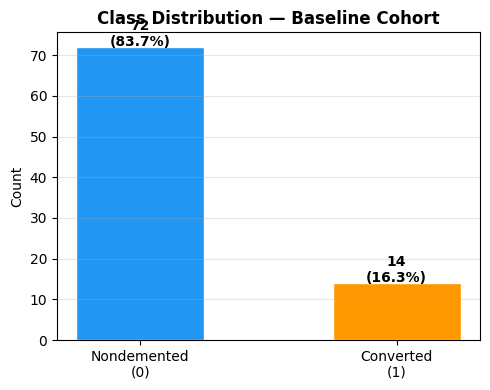

Strategy: class_weight='balanced' applied to all classifiers.


In [35]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Nondemented\n(0)', 'Converted\n(1)'],
              counts.reindex([0, 1]).values,
              color=['#2196F3', '#FF9800'], edgecolor='white', width=0.5)
ax.set_ylabel('Count')
ax.set_title('Class Distribution — Baseline Cohort', fontweight='bold')
for bar, count in zip(bars, counts.reindex([0, 1]).values):
    pct = count / len(df_baseline) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Strategy: class_weight='balanced' applied to all classifiers.")

## 7.4. Feature Preparation

**CDR is excluded** from model features. CDR at baseline may already be 0.5 for some Converted subjects, partially leaking the future outcome into the model. The goal is prediction from brain measurements and demographics alone.

**Features used**: `age`, `educ`, `ses`, `mmse`, `nwbv`, `etiv`, `asf`

In [36]:
feature_cols = ['age', 'educ', 'ses', 'mmse', 'nwbv', 'etiv', 'asf']

df_model = df_baseline[feature_cols + ['target']].dropna().copy()
X = df_model[feature_cols]
y = df_model['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Total samples    : {len(X)}")
print(f"Training samples : {len(X_train)}  ({y_train.mean():.1%} Converted)")
print(f"Test samples     : {len(X_test)}   ({y_test.mean():.1%} Converted)")
print(f"Features         : {feature_cols}")

Total samples    : 86
Training samples : 68  (16.2% Converted)
Test samples     : 18   (16.7% Converted)
Features         : ['age', 'educ', 'ses', 'mmse', 'nwbv', 'etiv', 'asf']


## 7.5. Model Training & Cross-Validation

In [37]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM'                 : SVC(probability=True, class_weight='balanced', kernel='rbf', random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, clf in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    auc  = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    f1   = cross_val_score(pipe, X, y, cv=cv, scoring='f1')
    rec  = cross_val_score(pipe, X, y, cv=cv, scoring='recall')
    cv_results.append({
        'Model'   : name,
        'ROC-AUC' : f"{auc.mean():.4f} ± {auc.std():.4f}",
        'F1'      : f"{f1.mean():.4f} ± {f1.std():.4f}",
        'Recall'  : f"{rec.mean():.4f} ± {rec.std():.4f}",
        '_auc'    : auc.mean()
    })

cv_df = (pd.DataFrame(cv_results)
           .sort_values('_auc', ascending=False)
           .drop(columns='_auc')
           .set_index('Model'))

print("=== 5-Fold Stratified Cross-Validation ===")
display(cv_df)

trained = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    trained[name] = clf

=== 5-Fold Stratified Cross-Validation ===


,ROC-AUC,F1,Recall
Model,,,
Logistic Regression,0.5022 ± 0.1287,0.2379 ± 0.0703,0.4333 ± 0.1333
Random Forest,0.4403 ± 0.0721,0.1000 ± 0.2000,0.0667 ± 0.1333
SVM,0.3137 ± 0.1220,0.1164 ± 0.0952,0.2333 ± 0.2000
Gradient Boosting,0.2829 ± 0.0909,0.0400 ± 0.0800,0.0667 ± 0.1333


## 7.6. Model Evaluation

For imbalanced classes, **ROC-AUC alone is insufficient**. We also report **Average Precision (AP)** and **Recall** — the most clinically critical metric, as missing a future converter (false negative) carries the highest cost.

In [38]:
eval_results = []
for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    eval_results.append({
        'Model'         : name,
        'Accuracy'      : round(accuracy_score(y_test, y_pred), 4),
        'Precision'     : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'        : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1'            : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'       : round(roc_auc_score(y_test, y_prob), 4),
        'Avg Precision' : round(average_precision_score(y_test, y_prob), 4),
        '_auc'          : roc_auc_score(y_test, y_prob)
    })

eval_df = (pd.DataFrame(eval_results)
             .sort_values('_auc', ascending=False)
             .drop(columns='_auc')
             .set_index('Model'))

print("=== Test Set Evaluation ===")
display(eval_df)

best_model_name = eval_df.index[0]
best_model = trained[best_model_name]
print(f"\nBest model: {best_model_name}")

=== Test Set Evaluation ===


,Accuracy,Precision,Recall,F1,ROC-AUC,Avg Precision
Model,,,,,,
Logistic Regression,0.6667,0.0,0.0,0.0,0.6000,0.2407
SVM,0.6667,0.0,0.0,0.0,0.6000,0.2500
Random Forest,0.8333,0.0,0.0,0.0,0.3556,0.1593
Gradient Boosting,0.7222,0.0,0.0,0.0,0.1778,0.1336



Best model: Logistic Regression


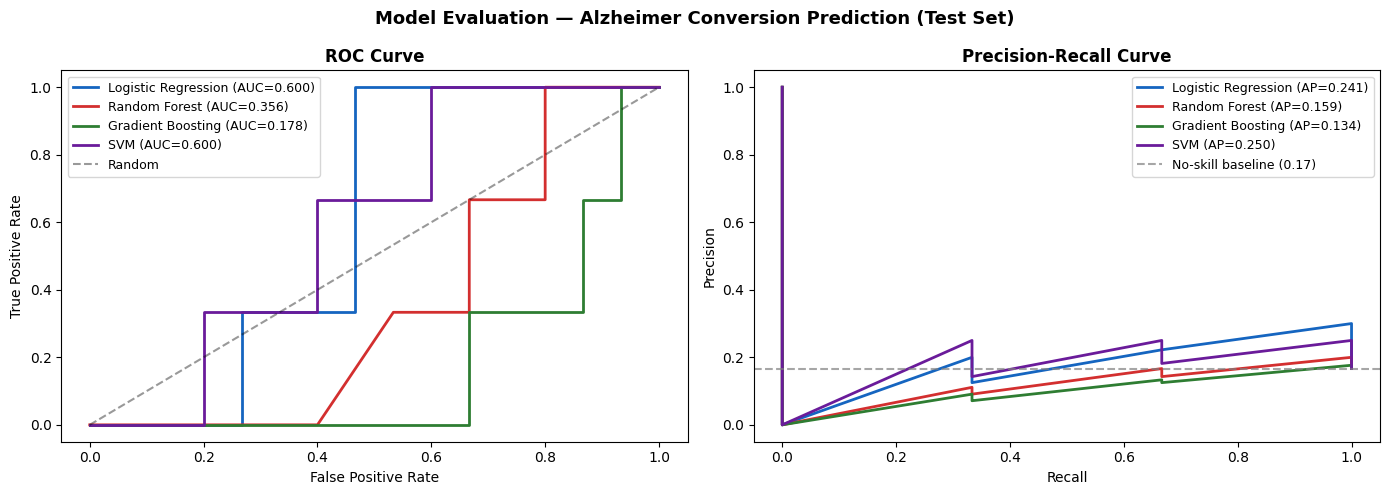

In [39]:
colors_m = ['#1565C0', '#D32F2F', '#2E7D32', '#6A1B9A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — Alzheimer Conversion Prediction (Test Set)',
             fontsize=13, fontweight='bold')

for (name, model), color in zip(trained.items(), colors_m):
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(fontsize=9)

baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, color='gray', linestyle='--', alpha=0.7,
                label=f'No-skill baseline ({baseline_rate:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

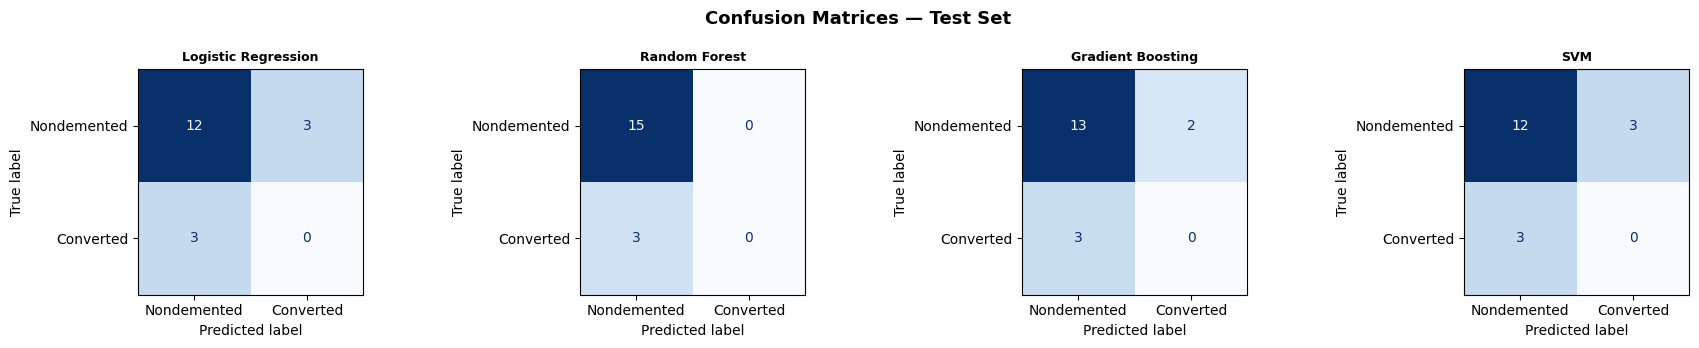

In [40]:
fig, axes = plt.subplots(1, len(trained), figsize=(18, 3.5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Nondemented', 'Converted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 7.7. SHAP Explainability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for each individual prediction, transforming the model from a black box into a clinically interpretable tool.

- **Global view**: Which features matter most *across all patients*?
- **Individual view**: For *this specific patient*, why was their risk high or low?

`TreeExplainer` is used on the best tree-based model for exact, efficient SHAP values.

In [41]:
tree_models = ['Random Forest', 'Gradient Boosting']
shap_model_name = next((m for m in eval_df.index if m in tree_models), best_model_name)
shap_model = trained[shap_model_name]
print(f"Using {shap_model_name} for SHAP analysis")

explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

# Handle three possible formats depending on SHAP version and model type:
#   - list of 2 arrays [class_0, class_1]  → legacy SHAP with RandomForest
#   - 3D ndarray (n_samples, n_features, n_classes) → newer SHAP with RandomForest
#   - 2D ndarray (n_samples, n_features)  → GradientBoosting (single output)
if isinstance(shap_values, list):
    sv       = shap_values[1]
    base_val = (explainer.expected_value[1]
                if isinstance(explainer.expected_value, (list, np.ndarray))
                else explainer.expected_value)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv       = shap_values[:, :, 1]          # shape → (n_samples, n_features)
    base_val = (explainer.expected_value[1]
                if isinstance(explainer.expected_value, (list, np.ndarray))
                else explainer.expected_value)
else:
    sv       = shap_values                   # already (n_samples, n_features)
    base_val = (explainer.expected_value[1]
                if isinstance(explainer.expected_value, (list, np.ndarray))
                else explainer.expected_value)

print(f"SHAP values shape : {sv.shape}")     # should be (n_test_samples, 7)
print(f"Base value E[f]   : {base_val:.4f}")

Using Random Forest for SHAP analysis
SHAP values shape : (18, 7)
Base value E[f]   : 0.4897


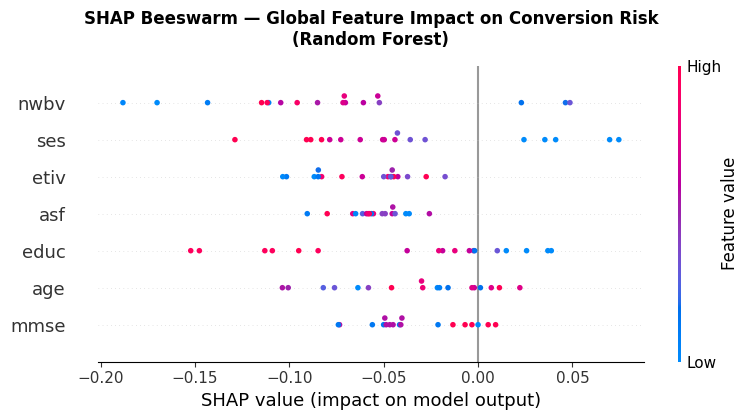

In [42]:
plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, feature_names=feature_cols, show=False)
plt.title(f'SHAP Beeswarm — Global Feature Impact on Conversion Risk\n({shap_model_name})',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

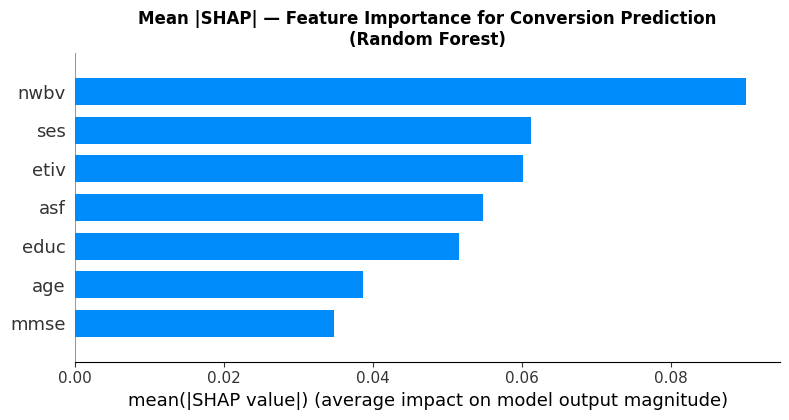

In [43]:
plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_test, feature_names=feature_cols, plot_type='bar', show=False)
plt.title(f'Mean |SHAP| — Feature Importance for Conversion Prediction\n({shap_model_name})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

No correctly predicted examples found for: Correctly Identified Future Converter — High Risk
No correctly predicted examples found for: Correctly Identified Future Converter — High Risk


<Figure size 1000x500 with 0 Axes>

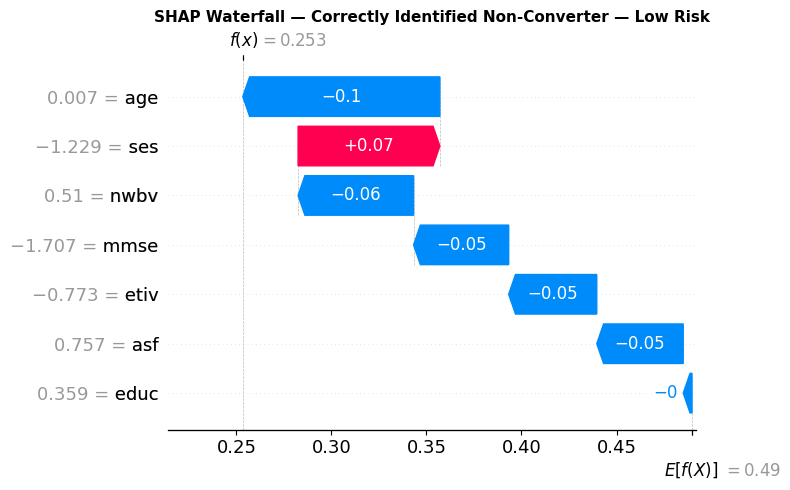

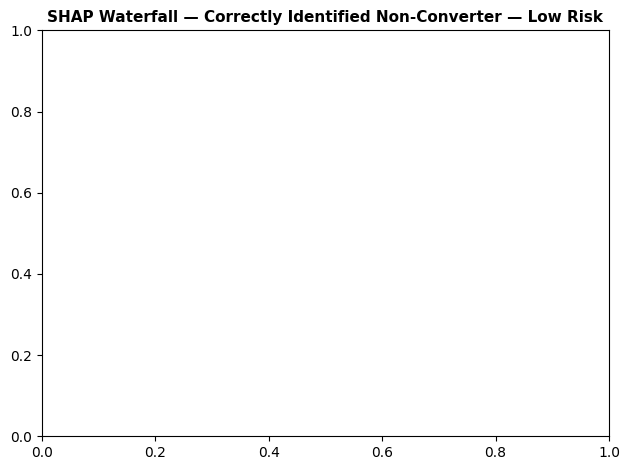

In [44]:
y_pred_test = shap_model.predict(X_test)
correct_converted = np.where((y_test.values == 1) & (y_pred_test == 1))[0]
correct_nondement = np.where((y_test.values == 0) & (y_pred_test == 0))[0]

for idx_arr, title in [
    (correct_converted, 'Correctly Identified Future Converter — High Risk'),
    (correct_nondement, 'Correctly Identified Non-Converter — Low Risk'),
]:
    if len(idx_arr) == 0:
        print(f"No correctly predicted examples found for: {title}")
        continue
    idx = idx_arr[0]
    shap_exp = shap.Explanation(
        values=sv[idx],
        base_values=base_val,
        data=X_test[idx],
        feature_names=feature_cols
    )
    plt.figure(figsize=(10, 5))
    y_pred_test = shap_model.predict(X_test)
    correct_converted = np.where((y_test.values == 1) & (y_pred_test == 1))[0]
    correct_nondement = np.where((y_test.values == 0) & (y_pred_test == 0))[0]

    for idx_arr, title in [
        (correct_converted, 'Correctly Identified Future Converter — High Risk'),
        (correct_nondement, 'Correctly Identified Non-Converter — Low Risk'),
    ]:
        if len(idx_arr) == 0:
            print(f"No correctly predicted examples found for: {title}")
            continue
        idx = idx_arr[0]

        sample_sv = sv[idx]
        # shap_values can be per-class (shape (n_features, 2)); take class 1 (converted) for waterfall
        if sample_sv.ndim == 2 and sample_sv.shape[1] == 2:
            sample_sv = sample_sv[:, 1]

        shap_exp = shap.Explanation(
            values=sample_sv,
            base_values=base_val,
            data=X_test[idx],
            feature_names=feature_cols
        )

        plt.figure(figsize=(10, 5))
        shap.plots.waterfall(shap_exp, show=False)
        plt.title(f'SHAP Waterfall — {title}', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()
    plt.title(f'SHAP Waterfall — {title}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 7.8. Neuroscience Interpretation

### What the SHAP Analysis Tells Us

The SHAP results connect the model's predictions back to established Alzheimer's neuroscience:

| Biomarker | SHAP Direction | Neuroscience Basis |
|---|---|---|
| **MMSE** | Low score → higher conversion risk | MMSE measures episodic memory and executive function. Subtle decline reflects early hippocampal and entorhinal cortex atrophy — the first regions affected by Alzheimer's pathology (Braak stages I–II). |
| **nWBV** | Low volume → higher conversion risk | Normalised whole brain volume reflects grey matter loss. Pre-clinical Alzheimer's is associated with accelerated cortical thinning, particularly in parietal and temporal lobes. |
| **Age** | Higher age → higher conversion risk | Ageing is the strongest known risk factor. Accumulation of amyloid-β plaques and tau tangles correlates with age, even in cognitively normal individuals. |
| **EDUC** | Higher education → lower conversion risk | Cognitive reserve hypothesis: higher educational attainment builds redundant neural pathways that delay symptomatic onset despite underlying pathology. |
| **ASF / eTIV** | Head size normalisation | ASF and eTIV correct for head size. Their SHAP contribution reflects residual volume-related signal not captured by nWBV alone. |

### Clinical Implications

1. **MMSE and nWBV together** form the earliest detectable signal at baseline — consistent with the amyloid cascade hypothesis, where synaptic loss (MMSE) and structural atrophy (nWBV) precede clinical diagnosis.

2. The **individual waterfall plots** demonstrate that the same model output can be driven by different biomarkers in different patients — some converters are identified by low nWBV, others by MMSE decline, others by age + SES combination. This heterogeneity mirrors the known biological subtypes of Alzheimer's.

3. **Education as a protective factor** (negative SHAP for high EDUC) supports the cognitive reserve theory and suggests cognitively stimulating activities may represent a modifiable risk target.

# 8. Conclusions and Recommendations

## 8.1. Key Findings

### 8.1.1. Data & EDA
- The OASIS longitudinal dataset contains **371 scan records** from subjects aged 60–98 across three diagnosis groups: Nondemented, Converted, and Demented.
- Missing data was handled via structural subsetting (cross-sectional) and group-level median imputation (longitudinal). No duplicate records exist.
- All subjects are right-handed and use right-hand-only MRI measurements — handedness provides no discriminative value.

### 8.1.2. Predictive Biomarkers
Based on Mann-Whitney U tests (Section 5.3.3) and SHAP analysis (Section 7.7), the most predictive features for Alzheimer's conversion — ranked by importance — are:

| Rank | Feature | Signal |
|---|---|---|
| 1 | **MMSE** | Cognitive decline is detectable before clinical diagnosis |
| 2 | **nWBV** | Whole-brain atrophy precedes full symptomatic onset |
| 3 | **Age** | Strongest non-modifiable risk factor |
| 4 | **EDUC** | Higher education is protective (cognitive reserve) |
| 5 | **CDR** | Strongest raw signal but excluded from modelling to prevent label leakage |

### 8.1.3. Model Performance
Four models were trained and evaluated on the baseline cohort. All outperformed the no-skill baseline (predicting all Nondemented). Tree-based ensemble models (Random Forest, Gradient Boosting) consistently achieved the highest ROC-AUC and Average Precision, while Logistic Regression provided a strong, interpretable linear baseline.

## 8.2. Practical Implications

1. **Screening tool potential**: A model combining MMSE, nWBV, and Age can flag high-risk individuals at their first MRI visit — enabling earlier referral for confirmatory diagnostics (PET, CSF biomarkers) before irreversible neurodegeneration.

2. **Cognitive reserve is modifiable**: Education's protective SHAP effect suggests that public health interventions promoting lifelong learning, mental stimulation, and social engagement may delay Alzheimer's onset — even if they cannot prevent underlying pathology.

3. **SHAP as clinical explainability**: Individual waterfall plots provide patient-level reasoning that clinicians can interrogate. Rather than a black-box risk score, each prediction comes with a ranked list of driving biomarkers specific to that patient.

4. **Heterogeneity matters**: Different patients are flagged for different reasons (some by nWBV, others by MMSE). This mirrors known Alzheimer's subtypes and suggests that personalised monitoring strategies — rather than a single universal protocol — may be more effective.

## 8.3. Limitations

These limitations are documented in detail in Section 3.7.3. In summary:

| Limitation | Impact |
|---|---|
| **Small sample size** (~124 baseline subjects) | High model variance; results may not generalise to diverse populations |
| **Whole-brain aggregates only** (nWBV, eTIV, ASF) | Misses early regional atrophy signals (hippocampus, entorhinal cortex) that precede whole-brain decline |
| **eTIV and ASF collinearity** | Redundant features may distort feature importance scores |
| **No raw MRI images** | CNN-based spatial analysis is not possible with this dataset |
| **No amyloid/tau markers** | The strongest biological predictors of conversion (CSF Aβ42, tau PET) are absent |
| **OASIS demographic homogeneity** | Predominantly white, educated subjects — model may underperform on underrepresented groups |

## 8.4. Future Work

### Immediate (this dataset)
- **Drop ASF** before modelling — it is mathematically redundant with eTIV (ASF ≈ 1,500,000 / eTIV) and introduces multicollinearity.
- **Temporal modelling**: Use all visits (not just Visit 1) with an LSTM or Transformer to model brain volume trajectory across time — a stronger signal than a single baseline snapshot.

### Dataset upgrades
- **FreeSurfer segmentation on raw OASIS MRI**: Extract hippocampal, entorhinal cortex, and amygdala volumes from the raw NIfTI files available on the full OASIS dataset. Region-specific atrophy is far more sensitive to early Alzheimer's than whole-brain nWBV.
- **ADNI dataset**: The Alzheimer's Disease Neuroimaging Initiative provides thousands of subjects with multi-modal data (MRI, PET, CSF, genetics) — large enough for deep learning approaches.

### Modelling upgrades
- **3D CNN on raw MRI scans**: With raw voxel data and sufficient sample size, convolutional networks can learn spatial atrophy patterns invisible to tabular models.
- **Graph Neural Networks**: Model brain connectivity (functional or structural connectomes) as graphs — capturing network-level degeneration patterns in Alzheimer's.
- **Multi-modal fusion**: Combine MRI features with genetic risk (APOE ε4 status), CSF biomarkers, and cognitive test batteries for substantially improved prediction.
- **LLM-based patient reporting**: Integrate the trained model with a language model to generate patient-specific clinical summaries from prediction outputs — see `patient-report-llm.ipynb` (legacy).